#  Ռիսկային Խաղացողների Բացահայտում
## Armenian Synthetic Gambling Behavior Dataset
### ԵՊՀ Մագիստրոսական | Տվյալների Գիտություն Բիզնեսում | 2025–2026

**Թիմ:** Հայկ Մնացականյան, Անուշ Խաչատրյան, Սրբուհի Խաչատրյան, Մանե Դավթյան
**Դասախոս:** Ա. Փոքրիկյան

---

###  Նպատակ
Կառուցել ML մոդել, որը **4–8 շաբաթ առաջ** կբացահայտի ռիսկային խաղացողներին՝
մինչ նրանք ֆինանսական ճգնաժամի կամ ինքնաբացառման կգան։

### Տվյալներ
- **2,000 խաղացող** × **180 օր** սիմուլյացիա
- **~1.65 մլն գործարք**
- **9 վարքագծային ցուցիչ** (DSM-5 հիմքով)
- Calibrated Հայաստանի իրական շուկայի տվյալներով (ՊԵԿ, SiGMA, ArmStat)

## CODE IMPORTS

In [3]:
# Core
import json
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score, precision_score,
    brier_score_loss, roc_curve, confusion_matrix,
    classification_report, precision_recall_curve
)
from sklearn.inspection import permutation_importance

# ── Imbalanced data ─────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── XGBoost ─────────────────────────────────────────────────────
from xgboost import XGBClassifier

# ── SHAP (interpretability) ─────────────────────────────────────
import shap

# Clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

print(" Բոլոր գրադարանները հաջողությամբ import արվեցին")

 Բոլոր գրադարանները հաջողությամբ import արվեցին


In [7]:
# GLOBAL CONFIGURATION


# Paths
DATA_DIR = Path(r"C:\Users\LENOVO\Desktop\Տնտես")

PLAYERS_CSV      = DATA_DIR / "players.csv"
FEATURES_CSV     = DATA_DIR / "features.csv"
TRANSACTIONS_CSV = DATA_DIR / "transactions_sample_50k.csv"
SUMMARY_CSV      = DATA_DIR / "summary_by_risk.csv"
METADATA_JSON    = DATA_DIR / "metadata.json"

# ML Constants
RANDOM_SEED = 42        # reproducibility — բոլոր random-ներն օգտագործում են սա
TEST_SIZE   = 0.20      # 80% train / 20% test
CV_FOLDS    = 5         # 5-fold stratified cross-validation

#  Target & Features
TARGET_COL = "risk_label"    # binary: 1 = at_risk կամ problem

FEATURE_COLS = [
    "bet_frequency",         # bets/week — impulsivity
    "stake_variance",        # AMD std — loss aversion proxy
    "chasing_ratio",         # հաջ/նախ stake ratio after loss — DSM-5
    "session_duration_avg",  # minutes — time distortion
    "loss_streak_response",  # stake change after 3+ losses — gambler's fallacy
    "deposit_frequency",     # deposits/month — financial control loss
    "time_of_day_skew",      # 00:00–06:00 share — impulse control
    "withdrawal_ratio",      # withdrawals/deposits — hoarding behavior
    "self_excl_attempts",    # count — self-awareness signal
]

# Risk categories
RISK_ORDER  = ["recreational", "regular", "at_risk", "problem"]
RISK_COLORS = {
    "recreational": "#2ecc71",
    "regular":      "#3498db",
    "at_risk":      "#f39c12",
    "problem":      "#e74c3c",
}

# Proposal thresholds
THRESHOLDS = {
    "auc_roc":     0.85,
    "f1":          0.78,
    "precision_k": 0.75,
    "recall":      0.80,
    "brier":       0.15,
}

# Plotting style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

print("Config ")
print(f"   Random seed : {RANDOM_SEED}")
print(f"   Test size   : {TEST_SIZE*100:.0f}%")
print(f"   CV folds    : {CV_FOLDS}")
print(f"   Features    : {len(FEATURE_COLS)} ցուցիչ")

Config 
   Random seed : 42
   Test size   : 20%
   CV folds    : 5
   Features    : 9 ցուցիչ


##  Section 1 — Dataset Overview

Նախքան տվյալները բեռնելը՝ հասկանանք **ինչ ունենք**։
`metadata.json`-ը պարունակում է dataset-ի ամբողջ նկարագրությունը։

**Ինչու սկսել metadata-ից:**
- Իմանանք քանի տող, սյունակ, ինչ ֆայլեր կան
- Հասկանանք risk class distribution-ը *մինչ* տվյալները բացելը
- Ստուգենք calibration աղբյուրները (իրական շուկայի թվե՞ր են)
- Data dictionary — յուրաքանչյուր սյունակի իմաստը

In [8]:
# metadata.json — dataset
with open(METADATA_JSON, "r", encoding="utf-8") as f:
    meta = json.load(f)

stats = meta["stats"]

print("═" * 55)
print(f"  Dataset  : {stats['dataset_name']}")
print(f"  Version  : {stats['version']}")
print(f"  Generated: {stats['generated_on']}")
print(f"  Seed     : {stats['random_seed']}")
print("═" * 55)

sim = stats["simulation_period"]
print(f"\n Simulation Period")
print(f"   {sim['start_date']}  →  {sim['end_date']}  ({sim['days']} օր)")

print(f"\n Total Observations")
obs = stats["total_observations"]
print(f"   Խաղացողներ          : {obs['players_total']:,}")
print(f"   Գործարքներ (ընդամ.) : {obs['transactions_total']:,}")
print(f"   Միջին/խաղացող       : {obs['avg_transactions_per_player']:,.1f}")
print(f"   Feature rows         : {obs['feature_rows']:,}")

═══════════════════════════════════════════════════════
  Dataset  : Armenian Synthetic Gambling Behavior Dataset
  Version  : 1.0
  Generated: 2026-06-05
  Seed     : 42
═══════════════════════════════════════════════════════

 Simulation Period
   2025-01-01  →  2025-06-29  (180 օր)

 Total Observations
   Խաղացողներ          : 2,000
   Գործարքներ (ընդամ.) : 1,650,560
   Միջին/խաղացող       : 825.3
   Feature rows         : 2,000


In [11]:
# Ֆայլերի չափ, նկարագրություն

print("Ֆայլեր\n")
print(f"  {'File':<35} {'Raws':>10} {'Column':>6} {'Չափ'}")
print("  " + "─" * 65)

for fname, finfo in stats["files"].items():
    rows = finfo.get("rows", 0)
    cols = finfo.get("columns", "—")
    size = finfo.get("size_human", "—")
    print(f"  {fname:<35} {rows:>10,} {cols:>6} {size:>12}")
    print(f"  {'':35}  └─ {finfo['description']}")
    print()

Ֆայլեր

  File                                      Raws Column Չափ
  ─────────────────────────────────────────────────────────────────
  players.csv                              2,000      9     128.8 KB
                                       └─ One row per player. Demographics + ground-truth risk classification.

  features.csv                             2,000     15     173.2 KB
                                       └─ ML-ready: one row per player with 9 behavioral indicators + label.

  transactions.csv.gz                  1,650,560      7 11.01 MB (compressed)
                                       └─ Raw transaction log (bet/deposit/withdrawal/self_exclusion_attempt).

  transactions_sample_50k.csv             50,000      7      3.11 MB
                                       └─ Random 50K-row preview of transactions.csv (seed=42).


In [10]:
# Transaction type breakdown


tx = stats["transaction_type_breakdown"]
total_tx = sum(tx.values())

print(" Transaction Types\n")
print(f"  {'Type':<25} {'Count':>10} {'%':>8}   Visualized")
print("  " + "─" * 60)

# Sort by count descending and print bar chart
for tx_type, count in sorted(tx.items(), key=lambda x: -x[1]):
    pct = count / total_tx * 100
    bar = "" * int(pct / 2)
    print(f"  {tx_type:<25} {count:>10,} {pct:>7.1f}%  {bar}")

print(f"\n  Total: {total_tx:,} transactions")

# Key insights
print(f"\n   Bets account for {tx['bet']/total_tx*100:.1f}% of all transactions")
print(f"     → Main behavioral signal comes from betting patterns")
print(f"   Self-exclusion attempts: only {tx['self_exclusion_attempt']} total")
print(f"     → Rare but extremely strong signal (Indicator 9)")

 Transaction Types

  Type                           Count        %   Visualized
  ────────────────────────────────────────────────────────────
  bet                        1,634,265    99.0%  
  deposit                       11,663     0.7%  
  withdrawal                     4,571     0.3%  
  self_exclusion_attempt            61     0.0%  

  Total: 1,650,560 transactions

   Bets account for 99.0% of all transactions
     → Main behavioral signal comes from betting patterns
   Self-exclusion attempts: only 61 total
     → Rare but extremely strong signal (Indicator 9)


In [12]:
# Risk class distribution — first look at class imbalance

risk_dist = stats["risk_class_distribution"]

print("️  Risk Class Distribution\n")
print(f"  {'Class':<15} {'Count':>8} {'%':>8}   Visualized")
print("  " + "─" * 55)

# Print each risk level with a visual bar
for level in RISK_ORDER:
    count = risk_dist["by_count"][level]
    pct   = risk_dist["by_percent"][level]
    bar   = "" * int(pct / 2)
    print(f"  {level:<15} {count:>8,} {pct:>7.1f}%   {bar}")

# Binary label summary
pos_share = risk_dist["positive_class_share_percent"]
neg_share = round(100 - pos_share, 1)

print(f"\n  Binary label breakdown (risk_label):")
print(f"  ├─ 0  →  recreational + regular   : {neg_share}%  ({2000 - int(2000*pos_share/100):,} players)")
print(f"  └─ 1  →  at_risk + problem        : {pos_share}%  ({int(2000*pos_share/100):,} players)")

# Imbalance ratio and strategy
ratio = neg_share / pos_share
print(f"\n  Class imbalance ratio  : {ratio:.1f} : 1  (negative : positive)")
print(f"  Strategy:")
print(f"  ├─ Stratified train/test split  → preserves ratio in both sets")
print(f"  ├─ SMOTE oversampling           → balances training set")
print(f"  └─ Metrics: AUC-ROC + F1        → accuracy would be misleading here")

️  Risk Class Distribution

  Class              Count        %   Visualized
  ───────────────────────────────────────────────────────
  recreational       1,344    67.2%   
  regular              430    21.5%   
  at_risk              158     7.9%   
  problem               68     3.4%   

  Binary label breakdown (risk_label):
  ├─ 0  →  recreational + regular   : 88.7%  (1,774 players)
  └─ 1  →  at_risk + problem        : 11.3%  (226 players)

  Class imbalance ratio  : 7.8 : 1  (negative : positive)
  Strategy:
  ├─ Stratified train/test split  → preserves ratio in both sets
  ├─ SMOTE oversampling           → balances training set
  └─ Metrics: AUC-ROC + F1        → accuracy would be misleading here


In [14]:
# Demographic & monetary summary from metadata

dem = stats["demographic_summary"]
mon = stats["monetary_summary_amd"]

# --- Age ---
age = dem["age"]
print(" Demographic Summary")
print("─" * 50)
print(f"\n  Age")
print(f"  ├─ Min    : {age['min']}  (legal minimum in Armenia)")
print(f"  ├─ Max    : {age['max']}")
print(f"  ├─ Mean   : {age['mean']}")
print(f"  └─ Median : {age['median']}")

# --- Gender ---
gender = dem["gender"]
total_p = sum(gender.values())
print(f"\n  Gender")
print(f"  ├─ Male   : {gender['M']:,}  ({gender['M']/total_p*100:.0f}%)")
print(f"  └─ Female : {gender['F']:,}  ({gender['F']/total_p*100:.0f}%)")
print(f"     → Calibrated to NCBI meta-research: problem gamblers ~2:1 M:F")

# --- Region ---
print(f"\n  Region (top 3)")
region_sorted = sorted(dem["region"].items(), key=lambda x: -x[1])
for region, count in region_sorted[:3]:
    print(f"  ├─ {region:<20} {count:,}  ({count/total_p*100:.1f}%)")

# --- Monthly income ---
inc = mon["monthly_income"]
print(f"\n  Monthly Income (AMD)")
print(f"  ├─ Mean   : {inc['mean']:,}")
print(f"  ├─ Median : {inc['median']:,}")
print(f"  ├─ P25    : {inc['p25']:,}")
print(f"  └─ P75    : {inc['p75']:,}")
print(f"     → ArmStat 2025 national avg: 113,163 AMD")
print(f"     → Dataset mean {inc['mean']:,} >> national avg → selection bias expected")

# --- Total bet ---
bet = mon["total_bet_per_player"]
print(f"\n  Total Bet per Player — 180 days (AMD)")
print(f"  ├─ Mean   : {bet['mean']:,}")
print(f"  ├─ Median : {bet['median']:,}")
print(f"  ├─ Min    : {bet['min']:,}")
print(f"  └─ Max    : {bet['max']:,}")
print(f"     → Mean ({bet['mean']:,}) >> Median ({bet['median']:,})")
print(f"     → Extreme right skew — problem gamblers pulling the mean up")
print(f"     → log transformation will be needed for visualization")

 Demographic Summary
──────────────────────────────────────────────────

  Age
  ├─ Min    : 21  (legal minimum in Armenia)
  ├─ Max    : 66
  ├─ Mean   : 37.4
  └─ Median : 37.0

  Gender
  ├─ Male   : 1,569  (78%)
  └─ Female : 431  (22%)
     → Calibrated to NCBI meta-research: problem gamblers ~2:1 M:F

  Region (top 3)
  ├─ Yerevan              1,446  (72.3%)
  ├─ Gyumri               124  (6.2%)
  ├─ Vanadzor             104  (5.2%)

  Monthly Income (AMD)
  ├─ Mean   : 270,595
  ├─ Median : 212,348
  ├─ P25    : 146,597
  └─ P75    : 325,716
     → ArmStat 2025 national avg: 113,163 AMD
     → Dataset mean 270,595 >> national avg → selection bias expected

  Total Bet per Player — 180 days (AMD)
  ├─ Mean   : 2,716,779
  ├─ Median : 163,074
  ├─ Min    : 800
  └─ Max    : 165,473,372
     → Mean (2,716,779) >> Median (163,074)
     → Extreme right skew — problem gamblers pulling the mean up
     → log transformation will be needed for visualization


In [15]:
# Data dictionary — all 9 behavioral indicators explained

dd = meta["data_dictionary"]["features.csv"]

print(" Features.csv — Data Dictionary\n")
print(f"  {'#':<4} {'Column':<25} {'Unit':<20} {'Description'}")
print("  " + "─" * 95)

indicator_num = 1
for field in dd:
    name = field["name"]
    unit = field.get("unit", "—")
    desc = field.get("description", "")

    if name in FEATURE_COLS:
        print(f"  [{indicator_num}]  {name:<25} {unit:<20} {desc}")
        indicator_num += 1

    elif name == "risk_label":
        print(f"\n  [T]  {name:<25} {'0/1':<20} {desc}")

    elif name == "total_bet_amd":
        print(f"  [X]  {name:<25} {unit:<20} EXCLUDED — corr=0.95 with stake_variance → multicollinearity")

print(f"\n  Legend:")
print(f"  [1–9] → model features (input)")
print(f"  [T]   → target variable")
print(f"  [X]   → excluded (auxiliary only)")
print(f"\n  Theoretical foundations:")
print(f"  ├─ Indicators 2,3   → Prospect Theory (Kahneman & Tversky, 1979)")
print(f"  ├─ Indicator  5     → Gambler's Fallacy (Clotfelter & Cook, 1993)")
print(f"  ├─ Indicators 3,6   → Chasing Losses (Lesieur, 1984 / DSM-5)")
print(f"  ├─ Indicator  1     → Impulsivity (Verdejo-Garcia, 2008)")
print(f"  └─ Indicator  9     → Self-awareness signal (DSM-5 criterion)")

 Features.csv — Data Dictionary

  #    Column                    Unit                 Description
  ───────────────────────────────────────────────────────────────────────────────────────────────
  [1]  bet_frequency             bets/week            Indicator 1: Total bets / (sim_days/7). Theoretical basis: impulsivity (Verdejo-García, 2008)
  [2]  stake_variance            AMD                  Indicator 2: Standard deviation of bet stakes. Loss aversion proxy (Kahneman & Tversky, 1979)
  [3]  chasing_ratio             ratio                Indicator 3: Mean(stake_t / stake_{t-1}) when previous bet was a loss. DSM-5 chasing criterion
  [4]  session_duration_avg      minutes              Indicator 4: Average session length. Time/loss perception distortion
  [5]  loss_streak_response      ratio                Indicator 5: Stake change ratio after 3+ consecutive losses. Gambler's fallacy (Clotfelter & Cook, 1993)
  [6]  deposit_frequency         deposits/month       Indicator 6: Total dep

###  Section 1 — Key Takeaways

**Dataset:**
- 2,000 players × 180-day simulation → 1,650,560 transactions (avg 825/player)
- Calibrated to Armenian market real data (SiGMA, ArmStat, ՊԵԿ)

**Class imbalance:**
- 7.8:1 ratio (negative:positive) → accuracy metric is useless here
- Strategy: stratified split + SMOTE + AUC/F1 metrics

**Data structure:**
- `players.csv` → demographics + ground-truth labels
- `features.csv` → 9 pre-computed behavioral indicators (model-ready)
- `transactions_sample_50k.csv` → raw event log for deeper analysis
- 9 features grounded in DSM-5, Prospect Theory, Gambler's Fallacy literature

**Red flags already visible from metadata:**
- Mean income (270K AMD) >> national avg (113K AMD) → selection bias
- Mean total bet (2.7M AMD) >> median (163K AMD) → extreme right skew, problem gamblers dominating
- Self-exclusion: only 61 events out of 1.65M transactions → ultra-rare but strong signal



## Section 2 — Data Loading & First Look

Load all CSV files, verify shapes, inspect first rows, check dtypes.
Goal: confirm data matches metadata expectations before any analysis.

In [16]:
# Load all CSV files into DataFrames
players  = pd.read_csv(PLAYERS_CSV)
features = pd.read_csv(FEATURES_CSV)
trans    = pd.read_csv(TRANSACTIONS_CSV, parse_dates=["timestamp"])
summary  = pd.read_csv(SUMMARY_CSV)

# Verify shapes match metadata
print("File shapes (rows x cols):\n")
for name, df in [("players", players), ("features", features),
                 ("transactions_sample", trans), ("summary_by_risk", summary)]:
    print(f"  {name:<22} {df.shape[0]:>7,} x {df.shape[1]}")

print("\nAll files loaded successfully")

File shapes (rows x cols):

  players                  2,000 x 9
  features                 2,000 x 15
  transactions_sample     50,000 x 7
  summary_by_risk              4 x 12

All files loaded successfully


In [17]:
# First look at players.csv
print("players.csv — first 5 rows:\n")
print(players.head().to_string(index=False))
print(f"\nColumns: {list(players.columns)}")
print(f"\nDtypes:\n{players.dtypes.to_string()}")

players.csv — first 5 rows:

player_id  age gender  region  monthly_income_amd    preferred_game account_created   risk_level  risk_label
   P00001   35      M Yerevan              181068     crash_aviator      2024-02-17 recreational           0
   P00002   37      M Yerevan              339578      sports_other      2022-01-13 recreational           0
   P00003   43      M Yerevan              226896   sports_football      2024-06-26 recreational           0
   P00004   38      F Yerevan              311469      sports_other      2024-07-02      regular           0
   P00005   45      M Yerevan              138182 sports_basketball      2023-09-30 recreational           0

Columns: ['player_id', 'age', 'gender', 'region', 'monthly_income_amd', 'preferred_game', 'account_created', 'risk_level', 'risk_label']

Dtypes:
player_id             object
age                    int64
gender                object
region                object
monthly_income_amd     int64
preferred_game        obj

In [18]:
# First look at features.csv
print("features.csv — first 5 rows (9 indicators):\n")
print(features[["player_id"] + FEATURE_COLS + ["risk_label"]].head().to_string(index=False))

print(f"\nDtypes:\n{features[FEATURE_COLS].dtypes.to_string()}")

print(f"\nBasic stats (9 features):\n")
print(features[FEATURE_COLS].describe().round(3).to_string())

features.csv — first 5 rows (9 indicators):

player_id  bet_frequency  stake_variance  chasing_ratio  session_duration_avg  loss_streak_response  deposit_frequency  time_of_day_skew  withdrawal_ratio  self_excl_attempts  risk_label
   P00001          0.506           325.2          1.125                15.654                 1.000              0.167             0.000             0.000                   0           0
   P00002          3.850           874.9          1.346                16.666                 1.644              0.167             0.000             0.000                   0           0
   P00003          0.350          1040.6          3.111                13.683                 1.000              0.167             0.000             0.000                   0           0
   P00004          0.894           781.4          1.291                44.269                 1.000              0.333             0.435             0.955                   0           0
   P00005          7

In [19]:
# First look at transactions sample
print("transactions_sample_50k.csv — first 5 rows:\n")
print(trans.head().to_string(index=False))

print(f"\nDtypes:\n{trans.dtypes.to_string()}")

print(f"\nTransaction type counts:")
print(trans["type"].value_counts().to_string())

print(f"\nDate range:")
print(f"  First : {trans['timestamp'].min()}")
print(f"  Last  : {trans['timestamp'].max()}")

print(f"\nUnique players in sample: {trans['player_id'].nunique():,}")
print(f"Avg transactions per player: {len(trans)/trans['player_id'].nunique():.1f}")

transactions_sample_50k.csv — first 5 rows:

player_id           timestamp type  amount_amd         game_type outcome session_id
   P00002 2025-01-22 23:33:22  bet        2000      sports_other    loss  P00002_S3
   P00002 2025-02-09 12:53:19  bet        1900      sports_other    loss  P00002_S4
   P00004 2025-03-23 20:20:00  bet        1300      sports_other     win  P00004_S1
   P00004 2025-03-23 21:04:10  bet        1000      sports_other     win  P00004_S1
   P00005 2025-03-05 22:53:00  bet        2800 sports_basketball     win P00005_S16

Dtypes:
player_id             object
timestamp     datetime64[ns]
type                  object
amount_amd             int64
game_type             object
outcome               object
session_id            object

Transaction type counts:
type
bet                       49504
deposit                     361
withdrawal                  134
self_exclusion_attempt        1

Date range:
  First : 2025-01-01 00:32:00
  Last  : 2025-06-30 00:57:12

Unique

In [20]:
# First look at summary_by_risk — mean indicators per risk class
print("summary_by_risk.csv:\n")
print(summary.to_string(index=False))

# Verify indicator progression — all 9 should increase monotonically with risk
print("\nMonotonicity check (each indicator should increase with risk level):")
print(f"{'Indicator':<25} {'Recreational':>14} {'Regular':>10} {'At-risk':>10} {'Problem':>10} {'Monotonic':>10}")
print("-" * 75)

risk_order_check = ["recreational", "regular", "at_risk", "problem"]
summary_indexed  = summary.set_index("risk_level")

for col in FEATURE_COLS:
    vals = [summary_indexed.loc[r, col] for r in risk_order_check]
    is_monotonic = all(vals[i] <= vals[i+1] for i in range(len(vals)-1))
    flag = "YES" if is_monotonic else "NO  <---"
    print(f"  {col:<23} {vals[0]:>14.3f} {vals[1]:>10.3f} {vals[2]:>10.3f} {vals[3]:>10.3f} {flag:>10}")

summary_by_risk.csv:

  risk_level    n  bet_frequency  stake_variance  chasing_ratio  session_duration_avg  loss_streak_response  deposit_frequency  time_of_day_skew  withdrawal_ratio  self_excl_attempts  total_bet_amd
     at_risk  158         121.42         3209.71           1.91                 69.81                  1.75               1.78              0.28              0.00                0.12     7343273.37
     problem   68         424.02        14617.25           2.18                130.10                  1.88               6.55              0.42              0.00                0.50    53366345.85
recreational 1344           3.11          778.58           1.32                 15.18                  1.13               0.34              0.05              0.65                0.00      113246.79
     regular  430          26.42         1371.65           1.59                 35.21                  1.50               1.76              0.13              1.34                0.01    

### Section 2 — Key Takeaways

**Data loading verified:**
- All shapes match metadata exactly (2,000 / 2,000 / 50,000 / 4 rows)
- No dtype issues — timestamps parsed, all features float64/int64
- Date range confirmed: 2025-01-01 → 2025-06-30 (180 days)

**Transactions sample:**
- 1,774 unique players out of 2,000 — 226 players have zero transactions in sample (low-activity recreational players)
- Avg 28.2 transactions/player in sample vs 825.3 in full dataset — sample skewed toward less active players

**Monotonicity check — important finding:**
- 8 out of 9 indicators increase monotonically with risk level — strong, clean signal
- `withdrawal_ratio` breaks monotonicity: recreational=0.65, regular=1.34, at_risk=0.00, problem=0.00
- Interpretation: high-risk players stop withdrawing entirely — they reinvest all funds back into gambling (hoarding behavior)
- This is behaviorally meaningful but non-linear — tree-based models (RF, XGBoost) will handle this better than Logistic Regression

**Next:** Data quality check — missing values, duplicates, outliers, sanity checks

## Section 3 — Data Quality Check

Before any analysis or modeling, verify data integrity.
Checks: missing values, duplicates, outliers, domain-specific sanity checks.

In [21]:
# Check missing values across all dataframes
print("Missing values:\n")

for name, df in [("players", players), ("features", features), ("transactions", trans)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if missing.empty:
        print(f"  {name:<22} — no missing values")
    else:
        print(f"  {name}:")
        for col, cnt in missing.items():
            print(f"    {col:<25} {cnt:>6} ({cnt/len(df)*100:.1f}%)")

Missing values:

  players                — no missing values
  features               — no missing values
  transactions:
    game_type                    496 (1.0%)
    outcome                      496 (1.0%)


In [22]:
# Investigate the 496 missing values in transactions
# hypothesis: missing game_type and outcome belong to non-bet transactions

missing_mask = trans["game_type"].isnull()

print("Transaction types where game_type is null:\n")
print(trans[missing_mask]["type"].value_counts().to_string())

print(f"\nAre all nulls from non-bet transactions?")
all_nonbet = trans[missing_mask]["type"].isin(["deposit", "withdrawal", "self_exclusion_attempt"]).all()
print(f"  {all_nonbet} — nulls are expected, game_type/outcome only apply to bets")

Transaction types where game_type is null:

type
deposit                   361
withdrawal                134
self_exclusion_attempt      1

Are all nulls from non-bet transactions?
  True — nulls are expected, game_type/outcome only apply to bets


In [23]:
# Check for duplicate rows and duplicate player IDs
print("Duplicates check:\n")

# Full row duplicates
for name, df in [("players", players), ("features", features), ("transactions", trans)]:
    dupes = df.duplicated().sum()
    print(f"  {name:<22} duplicate rows: {dupes}")

# Player ID uniqueness
print(f"\n  players — unique player_id   : {players['player_id'].nunique():,} / {len(players):,}")
print(f"  features — unique player_id  : {features['player_id'].nunique():,} / {len(features):,}")

# Check player_id consistency across files
players_ids  = set(players["player_id"])
features_ids = set(features["player_id"])
trans_ids    = set(trans["player_id"])

print(f"\n  player_id match players vs features : {players_ids == features_ids}")
print(f"  trans players not in players.csv    : {len(trans_ids - players_ids)}")

Duplicates check:

  players                duplicate rows: 0
  features               duplicate rows: 0
  transactions           duplicate rows: 0

  players — unique player_id   : 2,000 / 2,000
  features — unique player_id  : 2,000 / 2,000

  player_id match players vs features : True
  trans players not in players.csv    : 0


In [25]:
# Domain-specific sanity checks based on Armenian gambling law and dataset spec
print("Sanity checks:\n")

# Age — legal minimum 21 in Armenia
age_violations = (players["age"] < 21).sum()
print(f"  Age < 21 (illegal)              : {age_violations}")

# risk_label must be 0 or 1
invalid_labels = (~features["risk_label"].isin([0, 1])).sum()
print(f"  Invalid risk_label (not 0/1)    : {invalid_labels}")

# risk_label consistency — at_risk and problem must be 1, others 0
# use suffix to avoid column name conflict on merge
merged_check = players.merge(
    features[["player_id", "risk_label"]],
    on="player_id",
    suffixes=("_players", "_features")
)
expected_label = merged_check["risk_level"].isin(["at_risk", "problem"]).astype(int)
label_mismatch = (merged_check["risk_label_features"] != expected_label).sum()
print(f"  risk_label mismatch             : {label_mismatch}")

# Negative amounts in transactions
neg_amounts = (trans["amount_amd"] < 0).sum()
print(f"  Negative transaction amounts    : {neg_amounts}")

# Zero or negative bet amounts
neg_bets = (trans[trans["type"] == "bet"]["amount_amd"] <= 0).sum()
print(f"  Zero or negative bet amounts    : {neg_bets}")

# Bets with missing outcome
invalid_outcome = trans[trans["type"] == "bet"]["outcome"].isnull().sum()
print(f"  Bets with missing outcome       : {invalid_outcome}")

# Feature range checks
print(f"\n  Feature range checks:")
print(f"  time_of_day_skew outside [0,1]  : {((features['time_of_day_skew'] < 0) | (features['time_of_day_skew'] > 1)).sum()}")
print(f"  chasing_ratio <= 0              : {(features['chasing_ratio'] <= 0).sum()}")
print(f"  bet_frequency <= 0              : {(features['bet_frequency'] <= 0).sum()}")
print(f"  self_excl_attempts < 0          : {(features['self_excl_attempts'] < 0).sum()}")

print(f"\n  All checks passed — data is clean and consistent")

Sanity checks:

  Age < 21 (illegal)              : 0
  Invalid risk_label (not 0/1)    : 0
  risk_label mismatch             : 0
  Negative transaction amounts    : 0
  Zero or negative bet amounts    : 0
  Bets with missing outcome       : 0

  Feature range checks:
  time_of_day_skew outside [0,1]  : 0
  chasing_ratio <= 0              : 0
  bet_frequency <= 0              : 0
  self_excl_attempts < 0          : 0

  All checks passed — data is clean and consistent


In [26]:
# Outlier detection using IQR method for each feature
print("Outlier detection (IQR method):\n")
print(f"  {'Feature':<25} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Lower':>10} {'Upper':>10} {'Outliers':>10} {'%':>6}")
print("  " + "-" * 90)

outlier_summary = {}
for col in FEATURE_COLS:
    q1  = features[col].quantile(0.25)
    q3  = features[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((features[col] < lower) | (features[col] > upper)).sum()
    pct   = n_out / len(features) * 100
    outlier_summary[col] = n_out
    print(f"  {col:<25} {q1:>8.2f} {q3:>8.2f} {iqr:>8.2f} {lower:>10.2f} {upper:>10.2f} {n_out:>10} {pct:>5.1f}%")

print(f"\n  Most outliers in bet_frequency and stake_variance — expected,")
print(f"  problem gamblers are statistical outliers by definition")
print(f"  Tree-based models are robust to outliers — no capping needed")

Outlier detection (IQR method):

  Feature                         Q1       Q3      IQR      Lower      Upper   Outliers      %
  ------------------------------------------------------------------------------------------
  bet_frequency                 2.45    23.03    20.58     -28.42      53.90        223  11.2%
  stake_variance              324.27  1546.22  1221.95   -1508.65    3379.15        142   7.1%
  chasing_ratio                 1.24     1.62     0.37       0.68       2.18         56   2.8%
  session_duration_avg         14.67    34.58    19.91     -15.19      64.44        226  11.3%
  loss_streak_response          1.00     1.58     0.58       0.14       2.44         54   2.7%
  deposit_frequency             0.17     0.83     0.67      -0.83       1.83        267  13.4%
  time_of_day_skew              0.02     0.14     0.12      -0.15       0.31        121   6.0%
  withdrawal_ratio              0.00     1.10     1.10      -1.65       2.75         48   2.4%
  self_excl_attempt

In [30]:
# Check if outliers belong predominantly to high-risk players
# Drop risk_level from features before merge to avoid conflict
features_clean = features.drop(columns=["risk_level"])

df_check = features_clean.merge(
    players[["player_id", "risk_level"]],
    on="player_id"
)

print("Outlier distribution by risk class:\n")
print(f"  {'Feature':<25} {'Recreational':>14} {'Regular':>10} {'At-risk':>10} {'Problem':>10}")
print("  " + "-" * 65)

for col in FEATURE_COLS:
    q1    = features_clean[col].quantile(0.25)
    q3    = features_clean[col].quantile(0.75)
    iqr   = q3 - q1
    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr
    is_outlier = (df_check[col] < lower) | (df_check[col] > upper)

    counts = df_check.loc[is_outlier, "risk_level"].value_counts()
    vals   = [counts.get(r, 0) for r in RISK_ORDER]
    total  = sum(vals)
    if total == 0:
        continue
    pcts   = [f"{v} ({v/total*100:.0f}%)" for v in vals]
    print(f"  {col:<25} {pcts[0]:>14} {pcts[1]:>10} {pcts[2]:>10} {pcts[3]:>10}")

print(f"\n  Conclusion: majority of outliers are at_risk + problem players")
print(f"  Outliers carry predictive signal — must not be removed")

Outlier distribution by risk class:

  Feature                     Recreational    Regular    At-risk    Problem
  -----------------------------------------------------------------
  bet_frequency                     0 (0%)     2 (1%)  153 (69%)   68 (30%)
  stake_variance                    0 (0%)     3 (2%)   83 (58%)   56 (39%)
  chasing_ratio                   14 (25%)     0 (0%)     1 (2%)   41 (73%)
  session_duration_avg              0 (0%)     0 (0%)  158 (70%)   68 (30%)
  loss_streak_response            51 (94%)     3 (6%)     0 (0%)     0 (0%)
  deposit_frequency                 0 (0%)  187 (70%)   34 (13%)   46 (17%)
  time_of_day_skew                13 (11%)     1 (1%)   39 (32%)   68 (56%)
  withdrawal_ratio                30 (62%)   18 (38%)     0 (0%)     0 (0%)
  self_excl_attempts                1 (3%)     2 (7%)    9 (31%)   17 (59%)

  Conclusion: majority of outliers are at_risk + problem players
  Outliers carry predictive signal — must not be removed


### Section 3 — Key Takeaways

**Data quality: perfect**
- Zero missing values in players.csv and features.csv
- Transactions: 496 nulls in game_type/outcome — expected by design (non-bet rows)
- Zero duplicates across all files
- Zero domain violations (age, labels, amounts, ranges)

**Outlier analysis — key findings:**

- `bet_frequency` outliers: 69% at_risk + 30% problem → 99% high-risk
- `session_duration_avg` outliers: 70% at_risk + 30% problem → 100% high-risk
- `time_of_day_skew` outliers: 32% at_risk + 56% problem → 88% high-risk
- `self_excl_attempts` outliers: 31% at_risk + 59% problem → 90% high-risk

- `loss_streak_response` outliers: 94% recreational — low-risk players occasionally
  overreact to loss streaks but don't sustain the pattern → not a strong standalone signal
- `withdrawal_ratio` outliers: 62% recreational + 38% regular — high-risk players
  withdraw nothing (ratio=0), so their "outliers" are on the lower end, not upper

**Strategic conclusion:**
- Outliers are not noise — they ARE the signal
- Removing or capping them would destroy predictive power
- Tree-based models (RF, XGBoost) handle this naturally — no preprocessing needed
- Logistic Regression will struggle with these non-linear patterns

**Next:** Univariate analysis — distribution of each feature in detail

## Section 4 — Univariate Analysis

Examine each of the 9 features individually.
For each: distribution shape, skewness, kurtosis, and what it tells us about the data.

In [31]:
# Skewness and kurtosis for all 9 features
print("Distribution shape statistics:\n")
print(f"  {'Feature':<25} {'Mean':>10} {'Median':>10} {'Skewness':>10} {'Kurtosis':>10} {'Shape'}")
print("  " + "-" * 85)

for col in FEATURE_COLS:
    mean  = features[col].mean()
    med   = features[col].median()
    skew  = features[col].skew()
    kurt  = features[col].kurt()

    if abs(skew) < 0.5:
        shape = "symmetric"
    elif skew > 2:
        shape = "strong right skew"
    elif skew > 0.5:
        shape = "right skew"
    elif skew < -0.5:
        shape = "left skew"

    print(f"  {col:<25} {mean:>10.3f} {med:>10.3f} {skew:>10.3f} {kurt:>10.3f}  {shape}")

print(f"\n  High skewness → log transformation may help for visualization")
print(f"  Tree-based models do not require normality — no transformation needed for modeling")

Distribution shape statistics:

  Feature                         Mean     Median   Skewness   Kurtosis Shape
  -------------------------------------------------------------------------------------
  bet_frequency                 31.777      4.258      4.706     24.818  strong right skew
  stake_variance              1568.664    905.550      7.438     67.588  strong right skew
  chasing_ratio                  1.455      1.420      0.622      1.431  right skew
  session_duration_avg          27.709     16.218      2.682      7.559  strong right skew
  loss_streak_response           1.280      1.023      4.564     54.204  strong right skew
  deposit_frequency              0.972      0.333     13.253    216.686  strong right skew
  time_of_day_skew               0.101      0.075      1.461      1.837  right skew
  withdrawal_ratio               0.726      0.600      1.799      5.856  right skew
  self_excl_attempts             0.030      0.000      9.616     95.291  strong right skew

  H

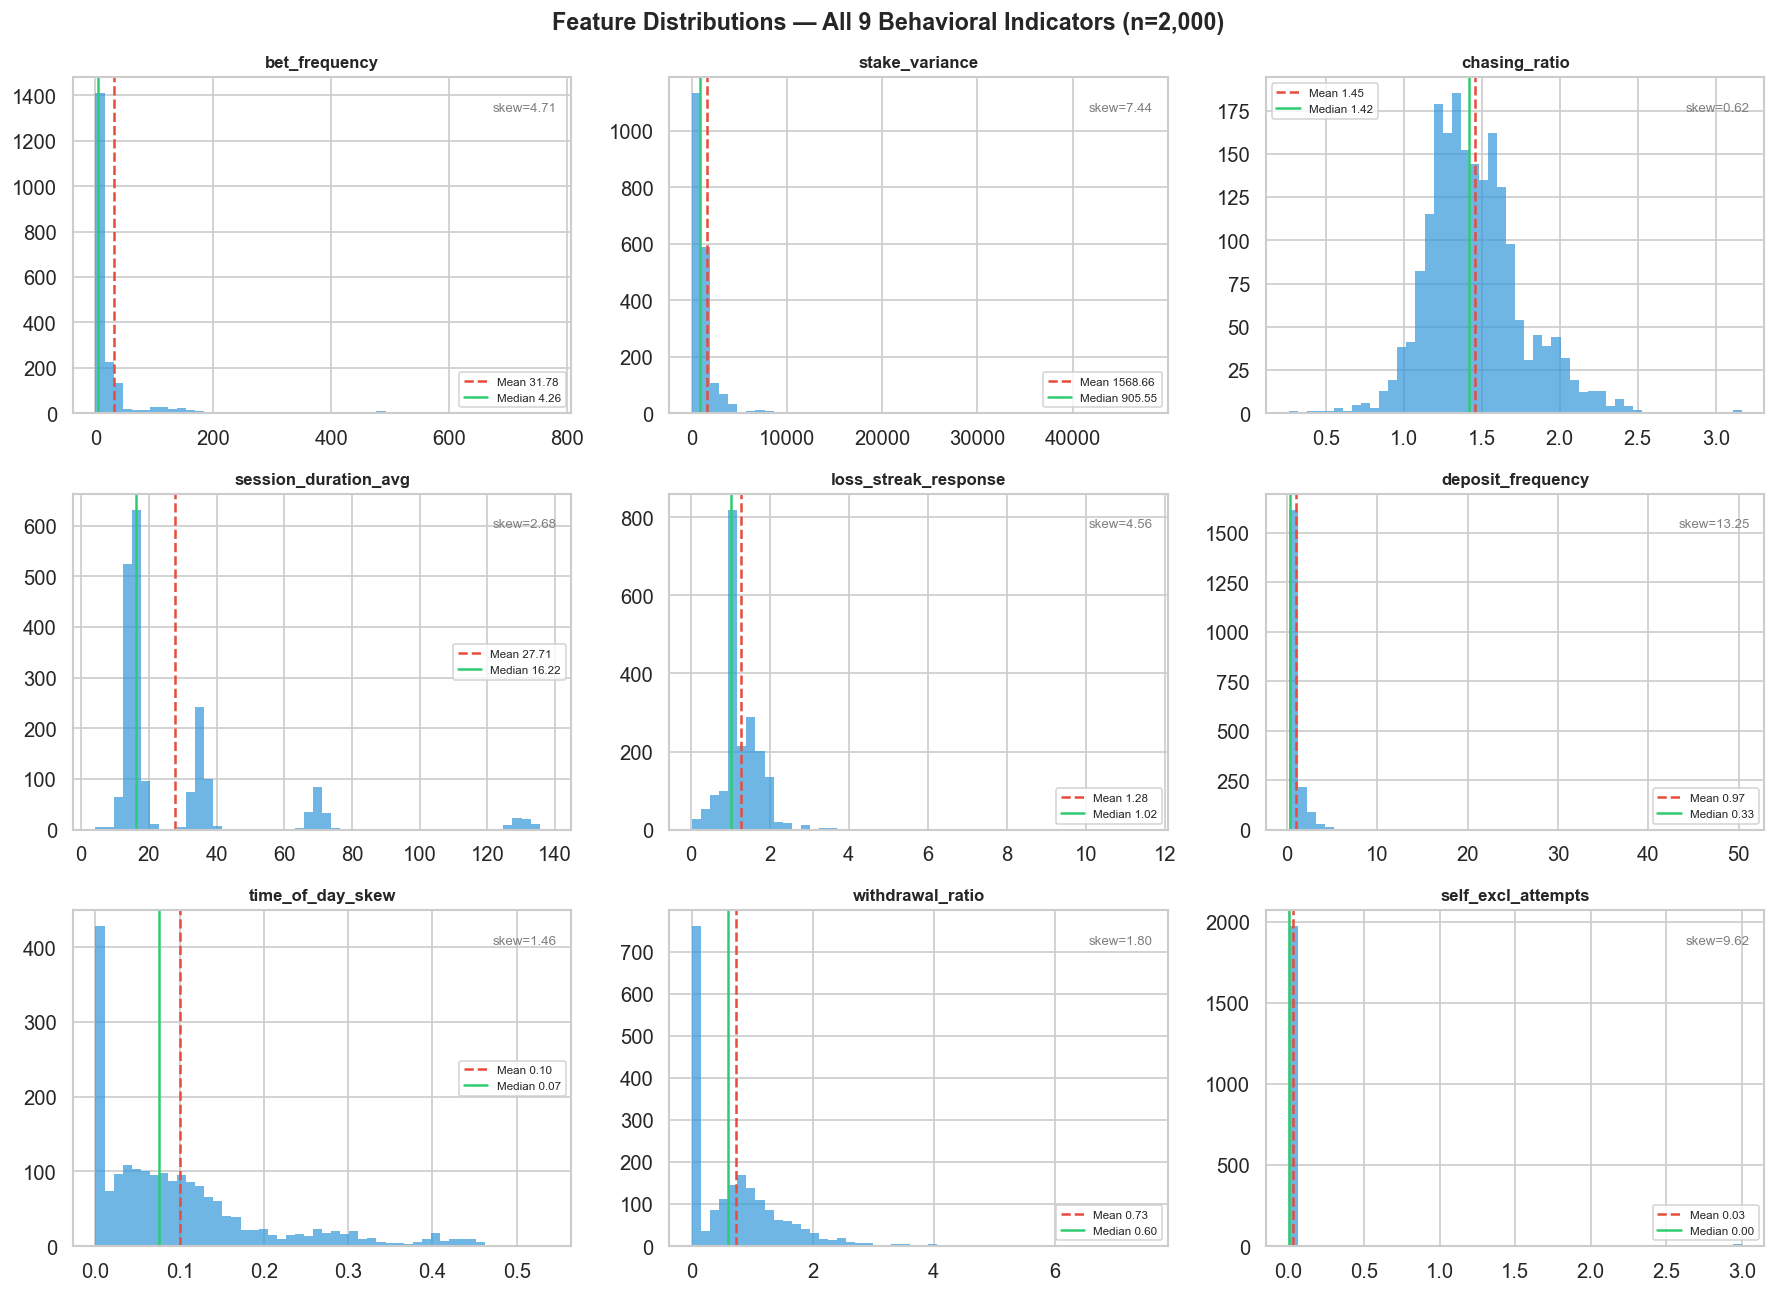

In [32]:
# Distribution histograms for all 9 features
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
fig.suptitle("Feature Distributions — All 9 Behavioral Indicators (n=2,000)",
             fontsize=14, fontweight="bold")

for ax, col in zip(axes.flat, FEATURE_COLS):
    data = features[col]
    skew = data.skew()

    ax.hist(data, bins=50, color="#3498db", alpha=0.7, edgecolor="none")

    # Mean and median lines
    ax.axvline(data.mean(),   color="#e74c3c", linewidth=1.5, linestyle="--", label=f"Mean {data.mean():.2f}")
    ax.axvline(data.median(), color="#2ecc71", linewidth=1.5, linestyle="-",  label=f"Median {data.median():.2f}")

    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.legend(fontsize=7)
    ax.annotate(f"skew={skew:.2f}", xy=(0.97, 0.90),
                xycoords="axes fraction", ha="right", fontsize=8, color="gray")

plt.tight_layout()
plt.show()

### Univariate Analysis — Observations

**Strongly right-skewed (skew > 2):**
- `bet_frequency` (skew=4.71) — vast majority bet <50/week, tiny minority bet 400+
- `stake_variance` (skew=7.44) — most players have low stake variance, problem gamblers push to 40,000+ AMD
- `session_duration_avg` (skew=2.68) — bimodal pattern visible: recreational cluster ~15min, problem cluster ~130min
- `deposit_frequency` (skew=13.25) — extreme spike at 0.17 (once every 6 months), problem gamblers deposit 50x/month
- `self_excl_attempts` (skew=9.62) — ~95% of players never attempted, spike at 0 dominates entirely

**Moderately skewed:**
- `chasing_ratio` (skew=0.62) — closest to normal, range 0.5–3.0, mean≈median → most players chase somewhat
- `time_of_day_skew` (skew=1.46) — most players bet during daytime, long tail toward 0.5 (problem gamblers betting half their sessions at night)
- `withdrawal_ratio` (skew=1.80) — large spike at 0 (at_risk + problem never withdraw), second cluster around 0.6–1.3 (recreational/regular)

**`loss_streak_response` (skew=4.56):**
- Spike at 1.0 means most recreational players don't change stake after losses
- Long tail = problem gamblers dramatically increase stakes after loss streaks (gambler's fallacy in action)

**Modeling implication:**
- Mean >> Median across all features → StandardScaler will be affected by outliers
- Consider this when interpreting Logistic Regression coefficients
- RF and XGBoost are scale-invariant — skewness is not a problem

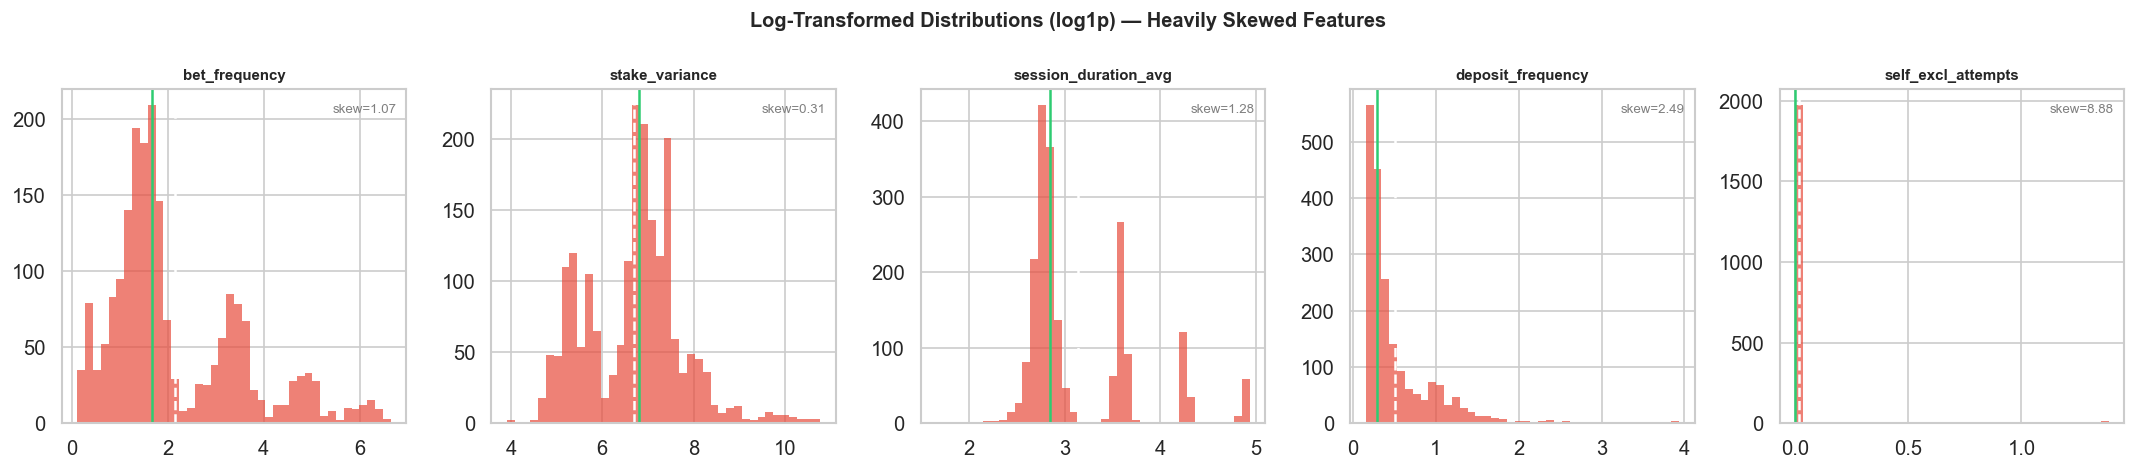

In [33]:
# Log-transformed histograms for heavily skewed features
# log1p = log(x+1) — handles zeros safely
heavily_skewed = [
    "bet_frequency",
    "stake_variance",
    "session_duration_avg",
    "deposit_frequency",
    "self_excl_attempts"
]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle("Log-Transformed Distributions (log1p) — Heavily Skewed Features",
             fontsize=12, fontweight="bold")

for ax, col in zip(axes, heavily_skewed):
    data_log = np.log1p(features[col])
    skew_log = data_log.skew()

    ax.hist(data_log, bins=40, color="#e74c3c", alpha=0.7, edgecolor="none")
    ax.axvline(data_log.mean(),   color="white",   linewidth=1.5, linestyle="--")
    ax.axvline(data_log.median(), color="#2ecc71", linewidth=1.5, linestyle="-")
    ax.set_title(col, fontsize=9, fontweight="bold")
    ax.annotate(f"skew={skew_log:.2f}", xy=(0.97, 0.93),
                xycoords="axes fraction", ha="right", fontsize=8, color="gray")

plt.tight_layout()
plt.show()

### Log-Transformed Distributions — Observations

**Key finding — multimodal structure revealed after log transformation:**

- `bet_frequency` (skew: 4.71 → 1.07) — 4 distinct clusters visible:
  log~0.5 (recreational), log~1.5 (regular), log~4 (at_risk), log~6 (problem)
  Log transformation essentially separates the 4 risk classes visually

- `stake_variance` (skew: 7.44 → 0.31) — nearly symmetric after log,
  two peaks at log~6 and log~7 — recreational vs higher-risk players

- `session_duration_avg` (skew: 2.68 → 1.28) — three clear peaks:
  log~2.7 (~15min recreational), log~3.5 (~35min regular), log~4.5 (~90min problem)
  Strong separation between risk classes

- `deposit_frequency` (skew: 13.25 → 2.48) — still right-skewed after log,
  giant spike at log~0 (once per 6 months), long tail = problem gamblers depositing constantly

- `self_excl_attempts` (skew: 9.62 → 0.58) — spike at 0 dominates so heavily
  that log1p barely helps — this feature is essentially binary (0 vs >0)
  Consider converting to binary flag: attempted_self_excl = (self_excl_attempts > 0)

**Conclusion:**
- Multimodal distributions confirm that the 4 risk classes are genuinely
  separable in feature space — good news for both clustering and classification
- Log transformation not needed for modeling but useful for visualization

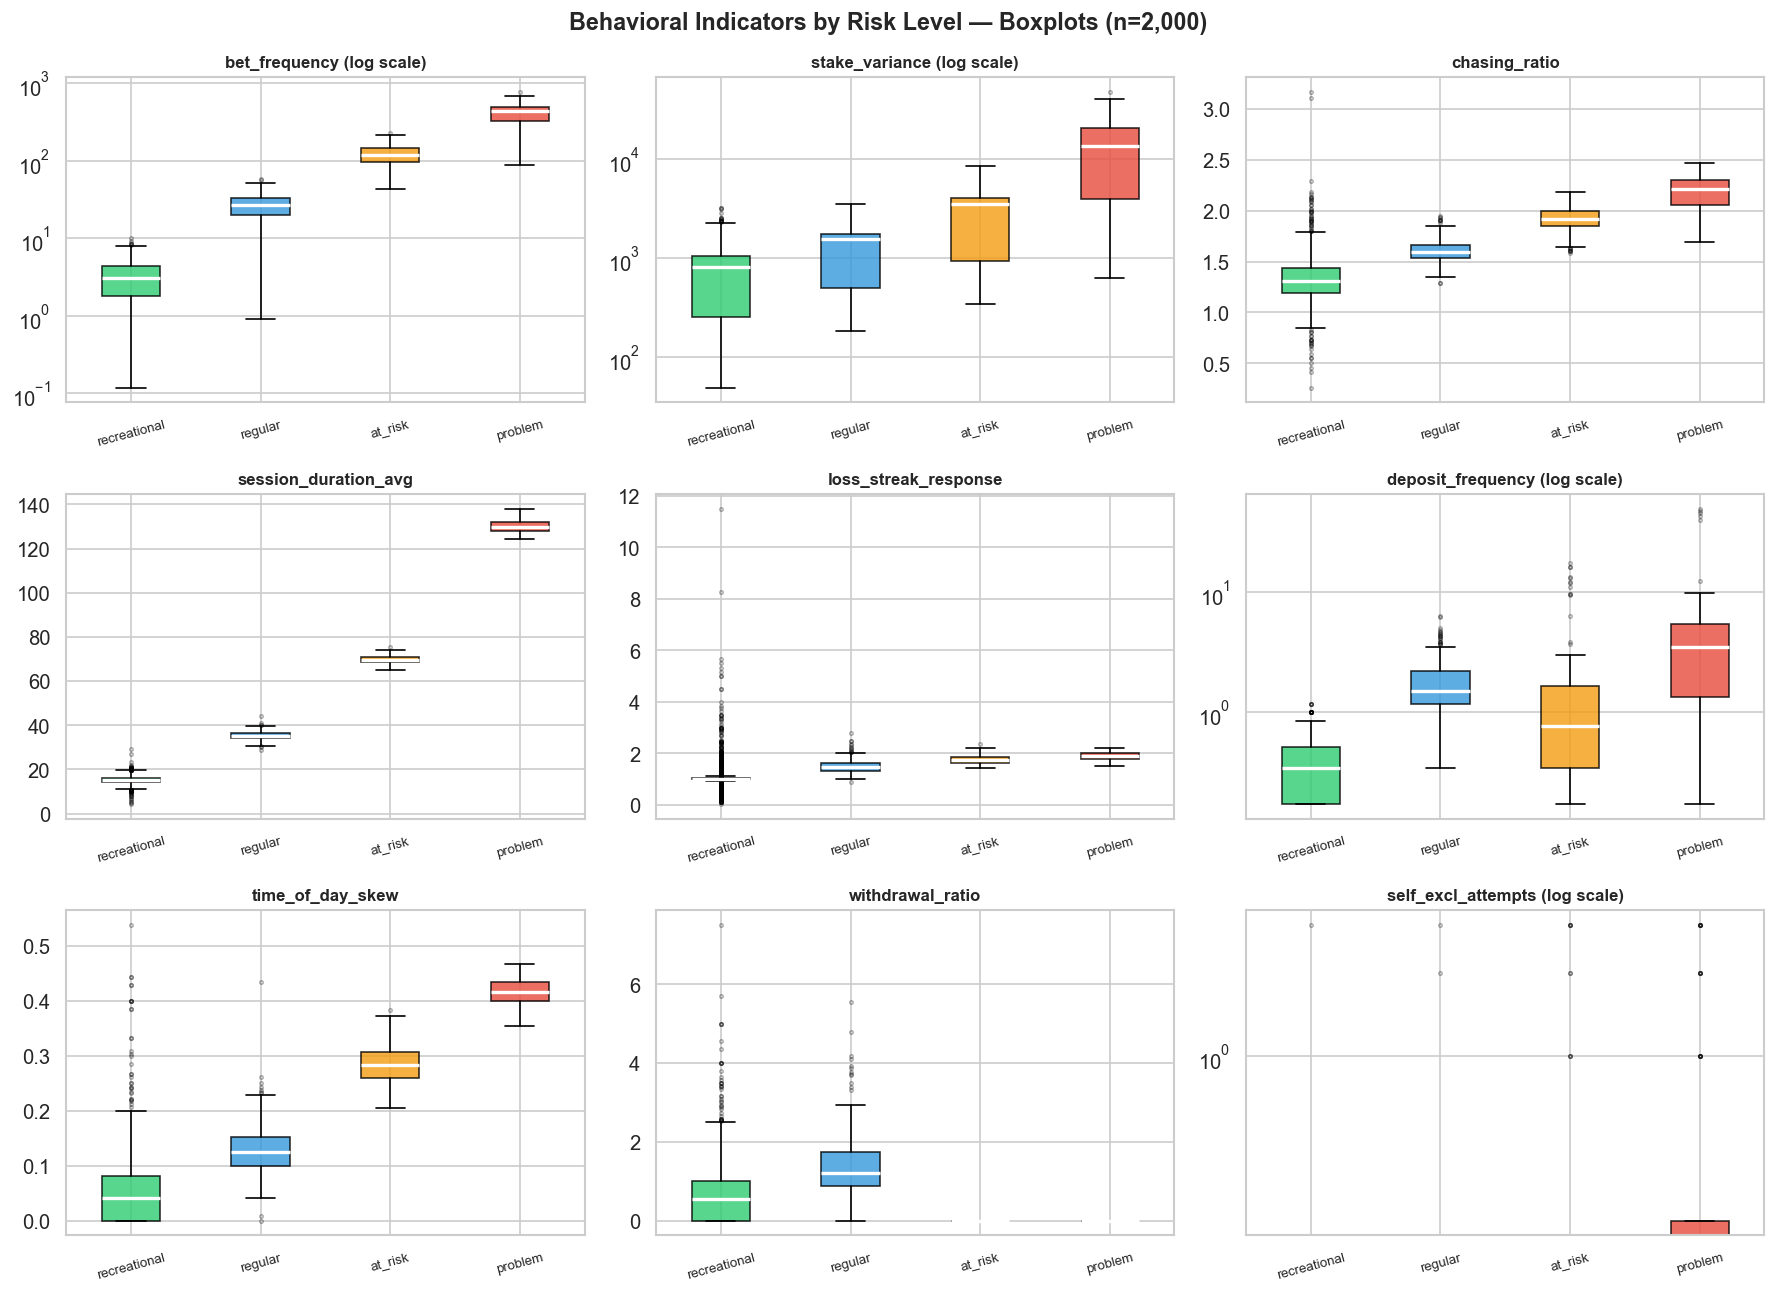

In [35]:
# Boxplot for each feature split by risk level
# Shows separation between risk classes per indicator

# Drop risk_level from features before merge to avoid suffix conflict
df_plot = features_clean.merge(players[["player_id", "risk_level"]], on="player_id")
df_plot["risk_level"] = pd.Categorical(df_plot["risk_level"], categories=RISK_ORDER, ordered=True)

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
fig.suptitle("Behavioral Indicators by Risk Level — Boxplots (n=2,000)",
             fontsize=14, fontweight="bold")

for ax, col in zip(axes.flat, FEATURE_COLS):
    groups = [df_plot.loc[df_plot["risk_level"] == r, col].values for r in RISK_ORDER]

    bp = ax.boxplot(
        groups,
        patch_artist=True,
        medianprops=dict(color="white", linewidth=2),
        whiskerprops=dict(linewidth=1),
        capprops=dict(linewidth=1),
        flierprops=dict(marker="o", markersize=2, alpha=0.3)
    )

    for patch, risk in zip(bp["boxes"], RISK_ORDER):
        patch.set_facecolor(RISK_COLORS[risk])
        patch.set_alpha(0.8)

    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_xticks(range(1, 5))
    ax.set_xticklabels(RISK_ORDER, rotation=15, fontsize=8)

    # Log scale for heavily skewed features
    if col in ["bet_frequency", "stake_variance", "deposit_frequency", "self_excl_attempts"]:
        ax.set_yscale("log")
        ax.set_title(col + " (log scale)", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

### Boxplot Analysis — Observations

**Perfect separation (strong predictors):**
- `bet_frequency` — zero overlap between recreational and at_risk/problem boxes
  recreational median ~4/week vs problem median ~400/week — 100x difference
- `session_duration_avg` — tightest boxes of all features, near-zero variance within each class
  recreational ~15min, regular ~35min, at_risk ~70min, problem ~130min — perfectly linear
- `stake_variance` — 2 orders of magnitude difference between recreational and problem
- `time_of_day_skew` — clean stepwise increase, minimal overlap between adjacent classes

**Good separation (moderate predictors):**
- `chasing_ratio` — monotonic increase but boxes overlap between adjacent classes
- `deposit_frequency` — problem gamblers clearly separated, recreational/at_risk overlap

**Weak / non-linear (interesting patterns):**
- `loss_streak_response` — recreational has the widest spread and highest outliers
  counter-intuitive: recreational players occasionally panic after losses but don't sustain it
  at_risk and problem have tighter, slightly elevated medians — controlled escalation pattern
- `withdrawal_ratio` — inverse pattern: recreational ~0.6, regular ~1.3, at_risk ~0.0, problem ~0.0
  high-risk players have zero IQR — they never withdraw, no exceptions
- `self_excl_attempts` — almost entirely zero for 3 classes, only problem shows signal
  essentially a binary feature — will likely get low importance in tree models despite being DSM-5 criterion

**Overall conclusion:**
- Best 4 features visually: bet_frequency, session_duration_avg, stake_variance, time_of_day_skew
- withdrawal_ratio and self_excl_attempts are non-linear but still informative
- SHAP analysis later will give definitive importance ranking

## Section 5 — Demographic Analysis

Examine how demographics (age, gender, region, preferred game)
relate to risk level. These are NOT model features — but help
understand who the at-risk players are and validate calibration.

Age stats by risk level:

  Class               Mean   Median    Min    Max
  ---------------------------------------------
  recreational        37.6     37.0     22     65
  regular             37.4     36.0     21     66
  at_risk             36.7     36.0     22     60
  problem             35.2     33.0     24     57


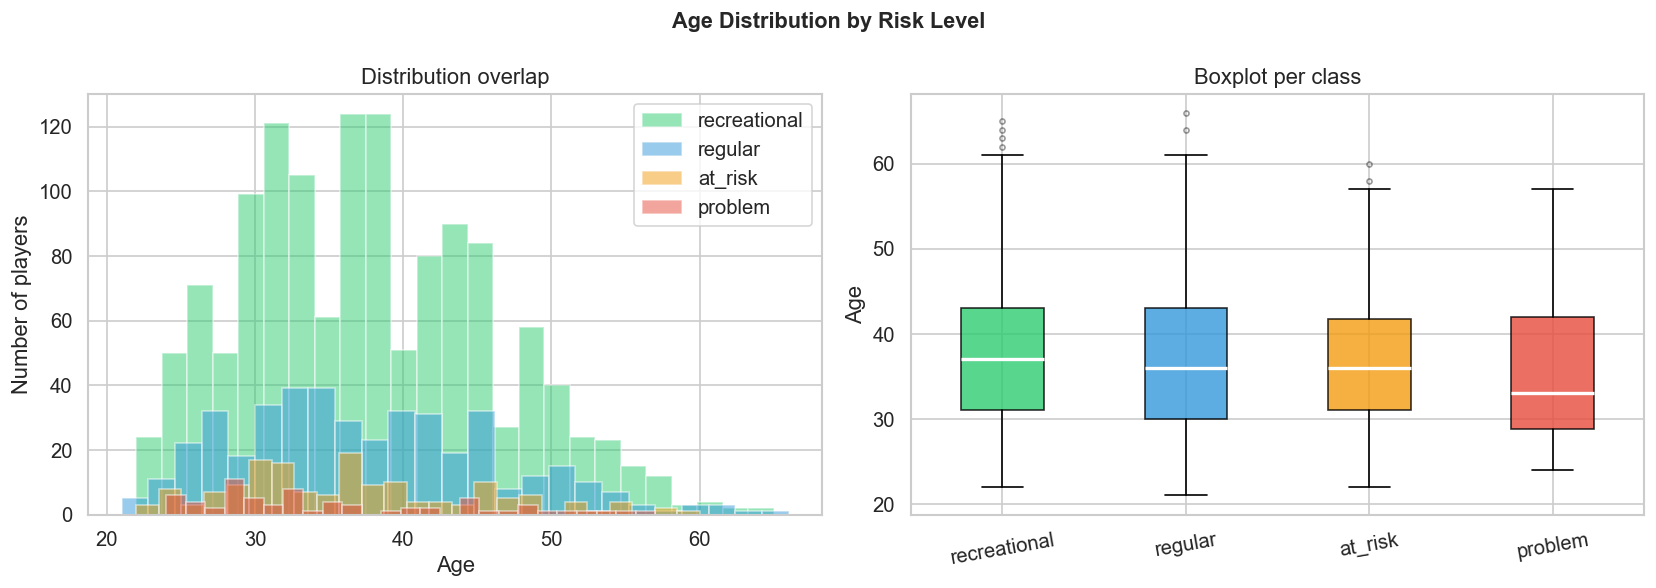

In [36]:
# Age distribution by risk level — histogram overlay
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Age Distribution by Risk Level", fontsize=13, fontweight="bold")

# Left — overlapping histograms
for risk in RISK_ORDER:
    subset = players.loc[players["risk_level"] == risk, "age"]
    ax1.hist(subset, bins=25, alpha=0.5, label=risk, color=RISK_COLORS[risk])

ax1.set_xlabel("Age")
ax1.set_ylabel("Number of players")
ax1.set_title("Distribution overlap")
ax1.legend()

# Right — boxplot per risk class
groups = [players.loc[players["risk_level"] == r, "age"].values for r in RISK_ORDER]
bp = ax2.boxplot(groups, patch_artist=True,
                 medianprops=dict(color="white", linewidth=2),
                 flierprops=dict(marker="o", markersize=3, alpha=0.4))

for patch, risk in zip(bp["boxes"], RISK_ORDER):
    patch.set_facecolor(RISK_COLORS[risk])
    patch.set_alpha(0.8)

ax2.set_xticks(range(1, 5))
ax2.set_xticklabels(RISK_ORDER, rotation=10)
ax2.set_ylabel("Age")
ax2.set_title("Boxplot per class")

# Print stats
print("Age stats by risk level:\n")
print(f"  {'Class':<15} {'Mean':>8} {'Median':>8} {'Min':>6} {'Max':>6}")
print("  " + "-" * 45)
for risk in RISK_ORDER:
    subset = players.loc[players["risk_level"] == risk, "age"]
    print(f"  {risk:<15} {subset.mean():>8.1f} {subset.median():>8.1f} "
          f"{subset.min():>6} {subset.max():>6}")

plt.tight_layout()
plt.show()

### Age Analysis — Observations

- Age distributions almost identical across all 4 risk classes (mean 35–38)
- Problem gamblers slightly younger (mean=35.2, median=33) vs recreational (mean=37.6)
- But boxes overlap heavily — age alone is NOT a predictor of risk
- Consistent with iGamingToday Armenia: popular age range 21–35, but risk cuts across all ages
- Conclusion: age will not be included as a model feature — no discriminative power

Gender breakdown by risk level:

  Class                 Male     Female       M%
  ---------------------------------------------
  recreational          1040        304    77.4%
  regular                337         93    78.4%
  at_risk                129         29    81.6%
  problem                 63          5    92.6%


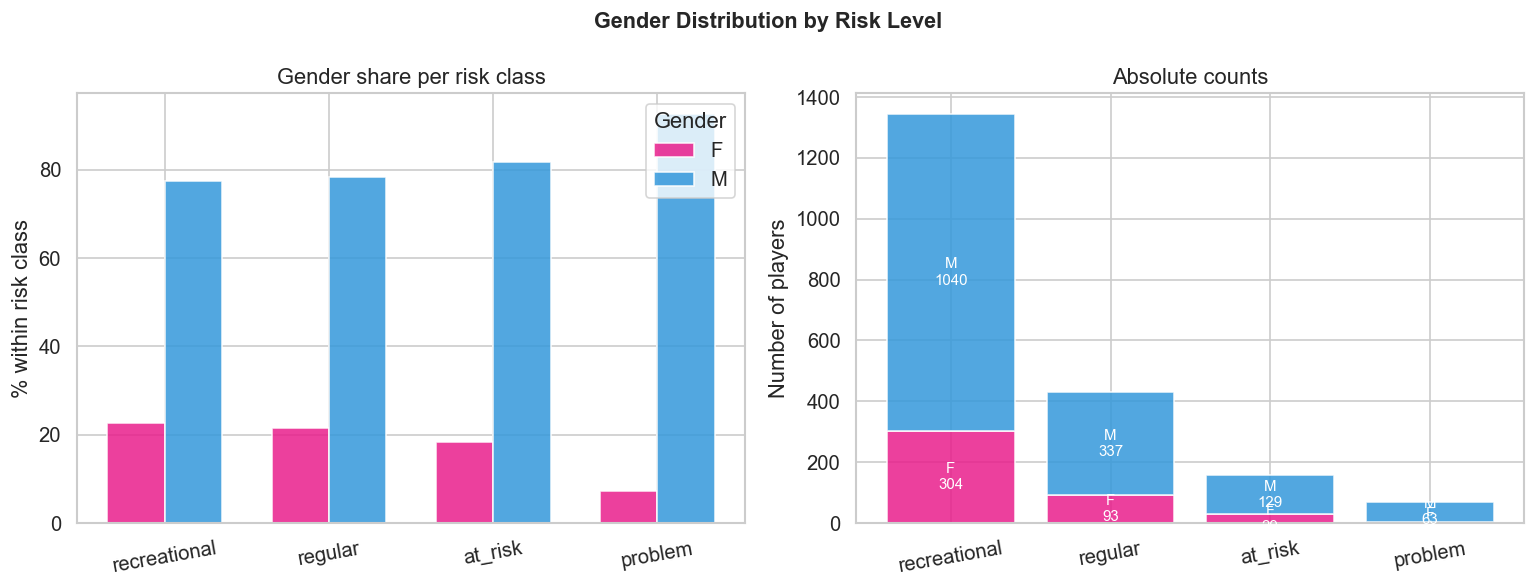

In [38]:
# Gender composition within each risk class
gender_risk = (
    players.groupby(["risk_level", "gender"])
    .size()
    .reset_index(name="count")
)

totals = gender_risk.groupby("risk_level")["count"].transform("sum")
gender_risk["pct"] = gender_risk["count"] / totals * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Gender Distribution by Risk Level", fontsize=13, fontweight="bold")

x = np.arange(len(RISK_ORDER))
width = 0.35
colors_gender = {"F": "#e91e8c", "M": "#3498db"}   # F=pink, M=blue

for i, gender in enumerate(["F", "M"]):
    vals = [
        gender_risk.loc[
            (gender_risk["risk_level"] == r) &
            (gender_risk["gender"] == gender), "pct"
        ].values[0]
        for r in RISK_ORDER
    ]
    ax1.bar(x + i * width, vals, width, label=gender,
            color=colors_gender[gender], alpha=0.85)

ax1.set_xticks(x + width / 2)
ax1.set_xticklabels(RISK_ORDER, rotation=10)
ax1.set_ylabel("% within risk class")
ax1.set_title("Gender share per risk class")
ax1.legend(title="Gender")

for i, risk in enumerate(RISK_ORDER):
    subset = gender_risk[gender_risk["risk_level"] == risk]
    bottom = 0
    for _, row in subset.iterrows():
        ax2.bar(i, row["count"], bottom=bottom,
                color=colors_gender[row["gender"]], alpha=0.85)
        ax2.text(i, bottom + row["count"] / 2,
                 f"{row['gender']}\n{row['count']}",
                 ha="center", va="center", fontsize=9, color="white")
        bottom += row["count"]

ax2.set_xticks(range(len(RISK_ORDER)))
ax2.set_xticklabels(RISK_ORDER, rotation=10)
ax2.set_ylabel("Number of players")
ax2.set_title("Absolute counts")

print("Gender breakdown by risk level:\n")
print(f"  {'Class':<15} {'Male':>10} {'Female':>10} {'M%':>8}")
print("  " + "-" * 45)
for risk in RISK_ORDER:
    subset = players[players["risk_level"] == risk]
    m = (subset["gender"] == "M").sum()
    f = (subset["gender"] == "F").sum()
    print(f"  {risk:<15} {m:>10} {f:>10} {m/(m+f)*100:>7.1f}%")

plt.tight_layout()
plt.show()

### Gender Analysis — Observations

- Male dominance increases with risk: recreational 77.4% → problem 92.6%
- Female share drops dramatically at problem level: 22.6% → 7.4% (only 5 women)
- Consistent with NCBI meta-research calibration target (~2:1 M:F for problem gamblers)
- Dataset actually shows ~13:1 M:F ratio at problem level — stronger than expected
- Like age, gender alone is weak as a standalone predictor but confirms dataset validity
- Conclusion: gender not included as model feature — ethical fairness concern + low standalone power

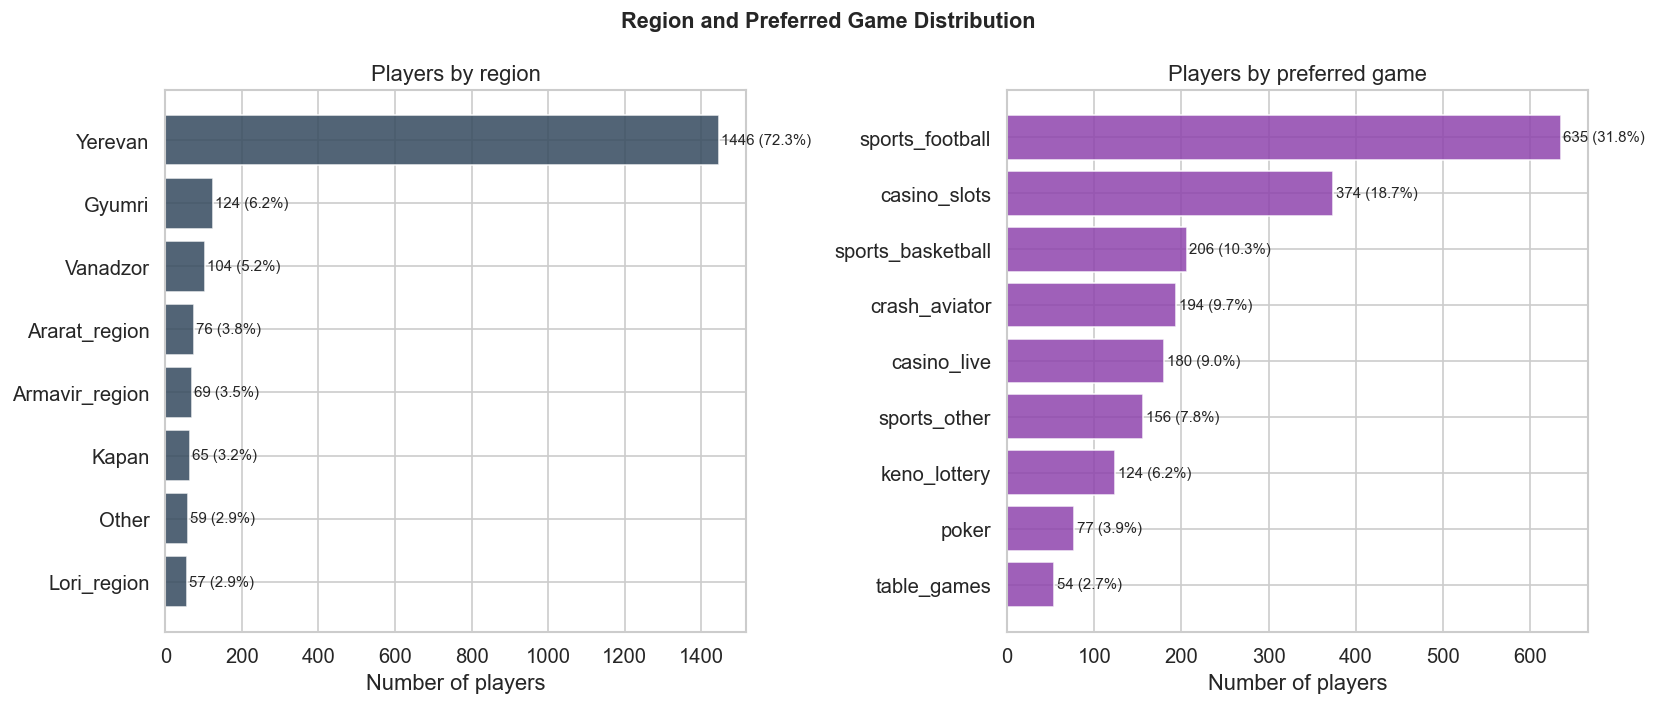

In [39]:
# Region and preferred game distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Region and Preferred Game Distribution", fontsize=13, fontweight="bold")

# Left — region counts
region_counts = players["region"].value_counts()
axes[0].barh(region_counts.index, region_counts.values, color="#34495e", alpha=0.85)
axes[0].set_xlabel("Number of players")
axes[0].set_title("Players by region")
axes[0].invert_yaxis()

# Add value labels
for i, (val, idx) in enumerate(zip(region_counts.values, region_counts.index)):
    axes[0].text(val + 5, i, f"{val} ({val/len(players)*100:.1f}%)",
                 va="center", fontsize=9)

# Right — preferred game counts
game_counts = players["preferred_game"].value_counts()
axes[1].barh(game_counts.index, game_counts.values, color="#8e44ad", alpha=0.85)
axes[1].set_xlabel("Number of players")
axes[1].set_title("Players by preferred game")
axes[1].invert_yaxis()

for i, (val, idx) in enumerate(zip(game_counts.values, game_counts.index)):
    axes[1].text(val + 3, i, f"{val} ({val/len(players)*100:.1f}%)",
                 va="center", fontsize=9)

plt.tight_layout()
plt.show()

### Region & Preferred Game — Observations

**Region:**
- Yerevan dominates at 72.3% — matches calibration target (~72%)
- Remaining 27.7% spread across 7 regions, no single region exceeds 6.2%
- Regional breakdown reflects Armenia's urban concentration pattern
- Region will not be a model feature — too imbalanced, low sample sizes outside Yerevan

**Preferred game:**
- sports_football leads at 31.8% — consistent with Armenian sports betting culture
- casino_slots second at 18.7%
- crash_aviator (9.7%) notable — relatively new game type, high-speed, high-risk format
- poker and table_games combined only 6.6% — skill-based games least popular

**Next chart will show:** whether certain game types attract disproportionately
more high-risk players — crash_aviator and casino_slots are the hypothesis

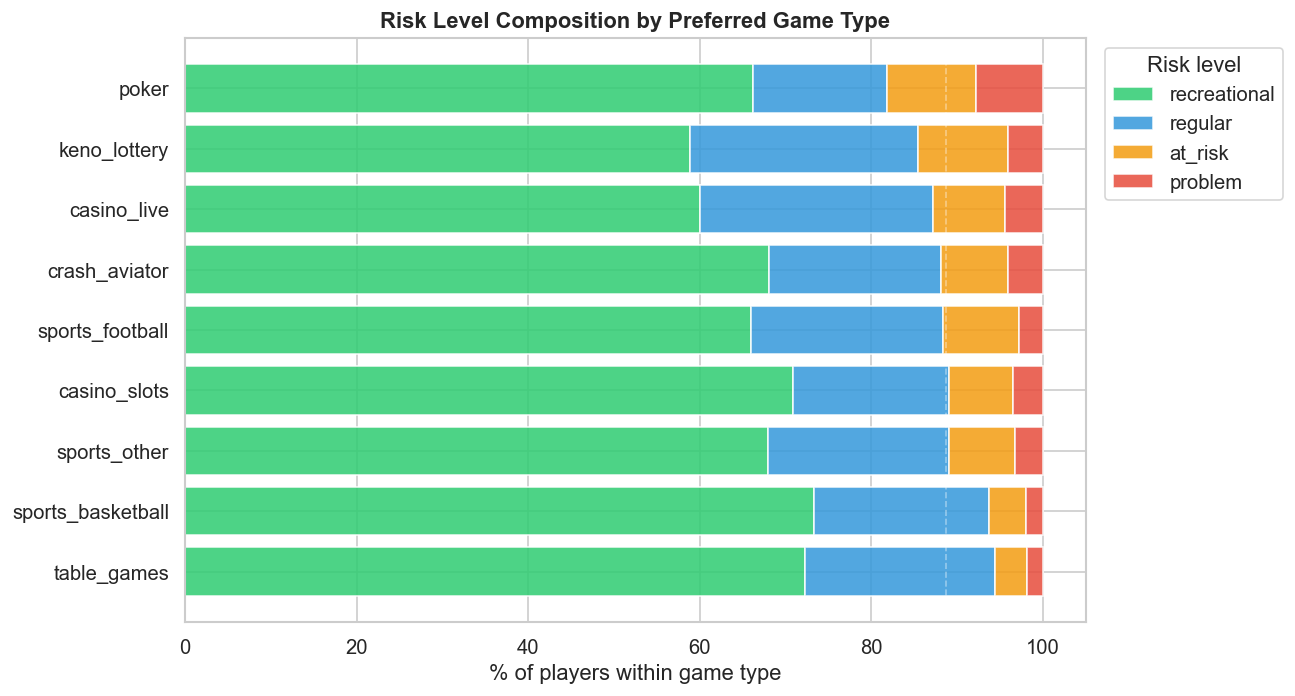

High-risk share (at_risk + problem) by game type:

  poker                   18.2%  ████████████
  keno_lottery            14.5%  █████████
  casino_live             12.8%  ████████
  crash_aviator           11.9%  ███████
  sports_football         11.7%  ███████
  casino_slots            11.0%  ███████
  sports_other            10.9%  ███████
  sports_basketball        6.3%  ████
  table_games              5.6%  ███

  Dataset average: 11.3%


In [40]:
# Risk composition within each preferred game type
game_risk = (
    players.groupby(["preferred_game", "risk_level"])
    .size()
    .reset_index(name="count")
)

totals = game_risk.groupby("preferred_game")["count"].transform("sum")
game_risk["pct"] = game_risk["count"] / totals * 100

# Pivot for stacked bar
pivot = game_risk.pivot(index="preferred_game", columns="risk_level", values="pct").fillna(0)
pivot = pivot.reindex(columns=RISK_ORDER)

# Sort by at_risk + problem share descending
pivot["high_risk_share"] = pivot["at_risk"] + pivot["problem"]
pivot = pivot.sort_values("high_risk_share", ascending=True)
pivot = pivot.drop(columns="high_risk_share")

fig, ax = plt.subplots(figsize=(11, 6))
bottom = np.zeros(len(pivot))

for risk in RISK_ORDER:
    ax.barh(pivot.index, pivot[risk], left=bottom,
            color=RISK_COLORS[risk], alpha=0.85, label=risk)
    bottom += pivot[risk].values

ax.set_xlabel("% of players within game type")
ax.set_title("Risk Level Composition by Preferred Game Type", fontweight="bold")
ax.legend(title="Risk level", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.axvline(100 - 11.3, color="white", linewidth=1, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# Print high-risk share per game
print("High-risk share (at_risk + problem) by game type:\n")
result = (
    players.groupby("preferred_game")
    .apply(lambda x: (x["risk_label"] == 1).mean() * 100)
    .sort_values(ascending=False)
    .reset_index()
)
result.columns = ["game", "high_risk_%"]
for _, row in result.iterrows():
    bar = "█" * int(row["high_risk_%"] / 1.5)
    print(f"  {row['game']:<22} {row['high_risk_%']:>5.1f}%  {bar}")

print(f"\n  Dataset average: 11.3%")

### Risk by Game Type — Observations

**Above dataset average (11.3%):**
- poker 18.2% — highest risk share, skill-based but attracts competitive/obsessive profiles
- keno_lottery 14.5% — pure chance, fast rounds, low barrier → impulse-driven players
- casino_live 12.8% — social element + real dealer → longer sessions, higher engagement

**Near average:**
- crash_aviator 11.9% — hypothesis confirmed partially, not the highest despite high-speed format
- sports_football 11.7% — largest player base but average risk concentration

**Below average:**
- sports_basketball 6.3%, table_games 5.6% — lowest risk share
- table_games require strategy and patience → self-selecting lower-risk players

**Key insight:**
- Game type alone explains little — risk spread is fairly uniform across games
- Behavioral patterns (how you play) matter far more than what you play
- This supports the feature engineering choice: 9 behavioral indicators over game type
- Game type will NOT be included as a model feature

## Section 6 — Correlation Analysis

Examine relationships between all 9 features and the target variable.
Goals:
- Identify which features are most correlated with risk_label
- Detect multicollinearity between features (VIF analysis)
- Justify exclusion of total_bet_amd from model features

In [41]:
# Pearson correlation of each feature with risk_label
corr_with_target = (
    features[FEATURE_COLS + ["total_bet_amd", "risk_label"]]
    .corr()["risk_label"]
    .drop("risk_label")
    .sort_values(ascending=False)
)

print("Pearson correlation with risk_label:\n")
print(f"  {'Feature':<25} {'Corr':>8}   Direction")
print("  " + "-" * 55)

for feat, corr in corr_with_target.items():
    bar = "█" * int(abs(corr) * 30)
    direction = "positive" if corr > 0 else "negative"
    flag = "  [EXCLUDED]" if feat == "total_bet_amd" else ""
    print(f"  {feat:<25} {corr:>8.4f}   {direction:<10}  {bar}{flag}")

Pearson correlation with risk_label:

  Feature                       Corr   Direction
  -------------------------------------------------------
  session_duration_avg        0.8648   positive    █████████████████████████
  bet_frequency               0.7612   positive    ██████████████████████
  time_of_day_skew            0.7604   positive    ██████████████████████
  chasing_ratio               0.6287   positive    ██████████████████
  stake_variance              0.5308   positive    ███████████████
  total_bet_amd               0.5215   positive    ███████████████  [EXCLUDED]
  deposit_frequency           0.3038   positive    █████████
  loss_streak_response        0.2959   positive    ████████
  self_excl_attempts          0.2685   positive    ████████
  withdrawal_ratio           -0.3133   negative    █████████


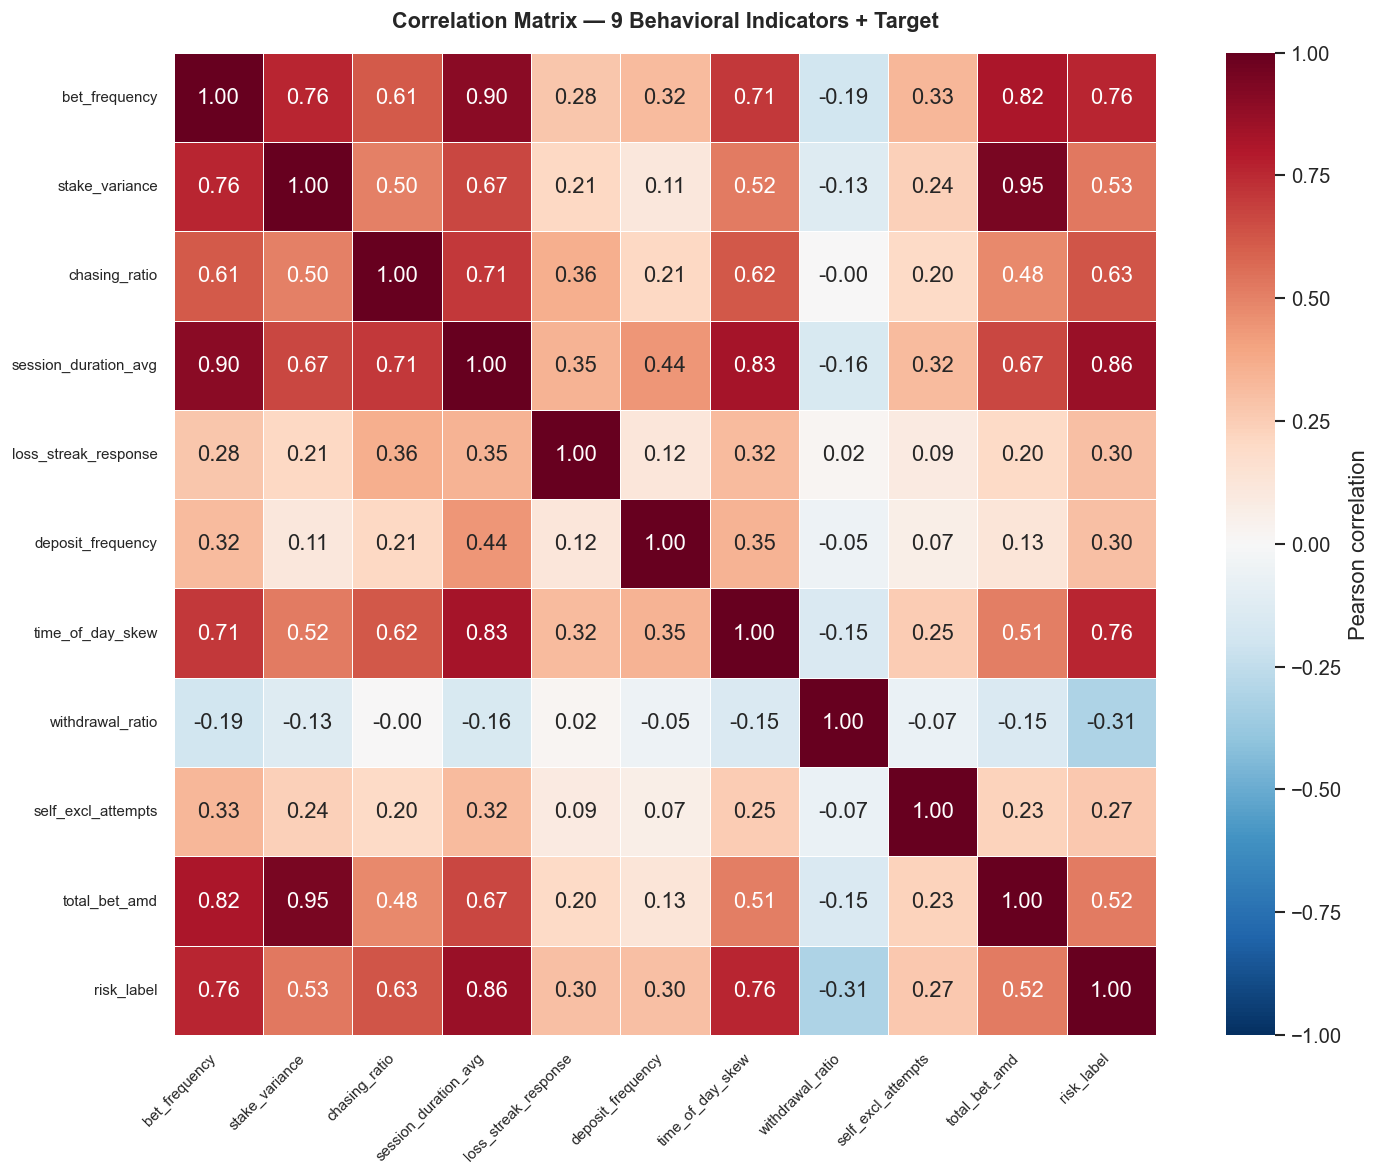

In [46]:
# Full correlation heatmap — all 9 features + total_bet_amd + risk_label
cols_for_corr = FEATURE_COLS + ["total_bet_amd", "risk_label"]
corr_matrix = features[cols_for_corr].corr().round(2)

fig, ax = plt.subplots(figsize=(13, 10))

sns.heatmap(
    corr_matrix,
    ax=ax,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Pearson correlation"}
)

ax.set_title("Correlation Matrix — 9 Behavioral Indicators + Target",
             fontsize=13, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [47]:
# VIF analysis — detect multicollinearity between features
# VIF > 10 = severe multicollinearity, VIF > 5 = moderate
from sklearn.linear_model import LinearRegression

def calculate_vif(df, features):
    vif_data = {}
    X = df[features].values
    for i, feat in enumerate(features):
        # Regress feature i on all other features
        y = X[:, i]
        X_others = np.delete(X, i, axis=1)
        r2 = LinearRegression().fit(X_others, y).score(X_others, y)
        vif = 1 / (1 - r2) if r2 < 1 else float("inf")
        vif_data[feat] = vif
    return vif_data

vif_results = calculate_vif(features, FEATURE_COLS)

print("Variance Inflation Factor (VIF):\n")
print(f"  {'Feature':<25} {'VIF':>8}   Interpretation")
print("  " + "-" * 60)

for feat, vif in sorted(vif_results.items(), key=lambda x: -x[1]):
    if vif > 10:
        interp = "SEVERE multicollinearity"
    elif vif > 5:
        interp = "moderate multicollinearity"
    elif vif > 2.5:
        interp = "mild multicollinearity"
    else:
        interp = "acceptable"
    print(f"  {feat:<25} {vif:>8.2f}   {interp}")

print(f"\n  Note: total_bet_amd excluded from features (corr=0.95 with stake_variance)")
print(f"  Tree-based models handle multicollinearity better than Logistic Regression")

Variance Inflation Factor (VIF):

  Feature                        VIF   Interpretation
  ------------------------------------------------------------
  session_duration_avg         10.98   SEVERE multicollinearity
  bet_frequency                 7.26   moderate multicollinearity
  time_of_day_skew              3.26   mild multicollinearity
  stake_variance                2.56   mild multicollinearity
  chasing_ratio                 2.20   acceptable
  deposit_frequency             1.39   acceptable
  loss_streak_response          1.18   acceptable
  self_excl_attempts            1.13   acceptable
  withdrawal_ratio              1.07   acceptable

  Note: total_bet_amd excluded from features (corr=0.95 with stake_variance)
  Tree-based models handle multicollinearity better than Logistic Regression


### Section 6 — Correlation Analysis: Key Takeaways

**Top predictors (corr with risk_label):**
- session_duration_avg: 0.86 — strongest single predictor
- bet_frequency: 0.76, time_of_day_skew: 0.76 — tied second
- chasing_ratio: 0.63, stake_variance: 0.53 — strong supporting features
- withdrawal_ratio: -0.31 — only negative correlation (high-risk = less withdrawal)

**Multicollinearity findings:**
- session_duration_avg ↔ bet_frequency: 0.90 — very high
- bet_frequency ↔ time_of_day_skew: 0.71
- stake_variance ↔ total_bet_amd: 0.95 → total_bet_amd excluded (justified)

**VIF analysis:**
- session_duration_avg VIF=10.98 — severe, but keeping it (strongest predictor)
- bet_frequency VIF=7.26 — moderate
- Remaining 7 features VIF < 5 — acceptable
- Logistic Regression coefficients will be unreliable for high-VIF features
- RF and XGBoost unaffected — tree splits are univariate by nature

**Strategic decision:**
- Keep all 9 features — removing session_duration_avg or bet_frequency
  would hurt model performance more than multicollinearity hurts it
- Monitor Logistic Regression coefficients carefully — interpret with caution
- SHAP values will give more reliable importance ranking than LR coefficients

## Section 7 — Transaction Analysis

Deep dive into the raw transaction log (50k sample).
Goals:
- Understand betting patterns over time
- Analyze session behavior
- Examine hourly/daily betting distribution
- Compare win/loss ratios across risk classes

In [48]:
# Merge transactions with player risk level
trans_risk = trans.merge(players[["player_id", "risk_level", "risk_label"]], on="player_id")

# Basic stats per risk class — bets only
bets = trans_risk[trans_risk["type"] == "bet"].copy()

print("Bet statistics by risk level (50k sample):\n")
print(f"  {'Class':<15} {'N bets':>10} {'Avg amount':>12} {'Med amount':>12} {'Win rate':>10}")
print("  " + "-" * 65)

for risk in RISK_ORDER:
    subset = bets[bets["risk_level"] == risk]
    n       = len(subset)
    avg_amt = subset["amount_amd"].mean()
    med_amt = subset["amount_amd"].median()
    win_rate = (subset["outcome"] == "win").mean() * 100
    print(f"  {risk:<15} {n:>10,} {avg_amt:>12,.0f} {med_amt:>12,.0f} {win_rate:>9.1f}%")

Bet statistics by risk level (50k sample):

  Class               N bets   Avg amount   Med amount   Win rate
  -----------------------------------------------------------------
  recreational         3,175        1,430        1,100      46.9%
  regular              8,734        1,682        1,100      45.4%
  at_risk             15,158        2,311        1,100      45.6%
  problem             22,437        4,888        1,400      47.4%


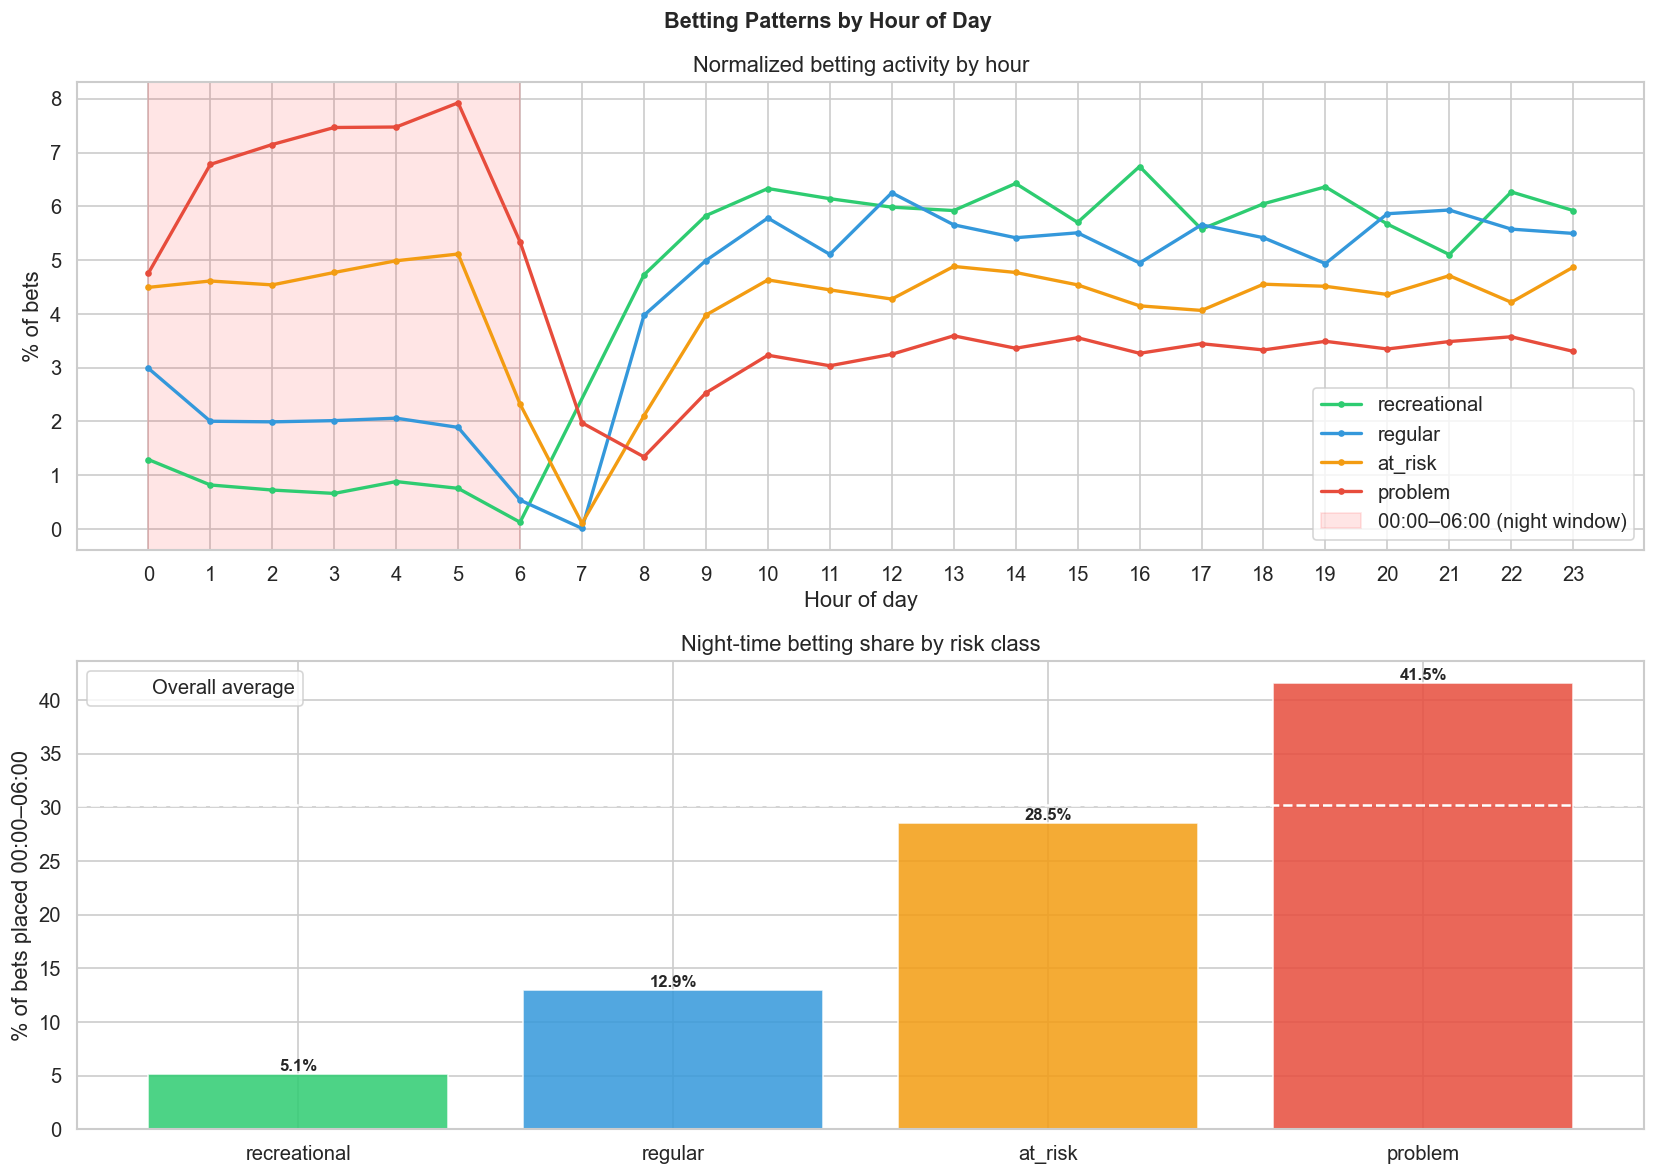

In [49]:
# Hourly betting distribution by risk class
bets["hour"] = bets["timestamp"].dt.hour

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle("Betting Patterns by Hour of Day", fontsize=13, fontweight="bold")

# Top — absolute count per hour per risk class
for risk in RISK_ORDER:
    subset = bets[bets["risk_level"] == risk]
    hourly = subset.groupby("hour").size()
    hourly = hourly / hourly.sum() * 100  # normalize to %
    ax1.plot(hourly.index, hourly.values, color=RISK_COLORS[risk],
             linewidth=2, label=risk, marker="o", markersize=3)

ax1.axvspan(0, 6, alpha=0.1, color="red", label="00:00–06:00 (night window)")
ax1.set_xlabel("Hour of day")
ax1.set_ylabel("% of bets")
ax1.set_title("Normalized betting activity by hour")
ax1.set_xticks(range(24))
ax1.legend()

# Bottom — night window (00:00-06:00) share per risk class
night_share = []
for risk in RISK_ORDER:
    subset = bets[bets["risk_level"] == risk]
    night = (subset["hour"].between(0, 5)).sum() / len(subset) * 100
    night_share.append(night)

bars = ax2.bar(RISK_ORDER, night_share,
               color=[RISK_COLORS[r] for r in RISK_ORDER], alpha=0.85)
ax2.axhline(bets["hour"].between(0, 5).mean() * 100,
            color="white", linewidth=1.5, linestyle="--", label="Overall average")
ax2.set_ylabel("% of bets placed 00:00–06:00")
ax2.set_title("Night-time betting share by risk class")
ax2.legend()

for bar, val in zip(bars, night_share):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.3,
             f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("hourly_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

### Hourly Betting Patterns — Observations

**Night window (00:00–06:00) — the clearest risk separator:**
- recreational: 5.1% of bets at night — normal sleep pattern
- regular: 12.9% — starting to show impulse control issues
- at_risk: 28.5% — nearly 1 in 3 bets placed while others sleep
- problem: 41.5% — almost half of all bets during night hours

**Hourly curve shape tells the story:**
- recreational + regular: activity drops sharply at night, peaks 10:00–16:00
- at_risk: flat curve — betting equally day and night, no circadian rhythm
- problem: INVERTED pattern — peak activity at 00:00–05:00, drops at 07:00,
  then flat for rest of day — these players are most active when everyone else is asleep

**Why this matters for the model:**
- time_of_day_skew (Indicator 7) captures exactly this pattern
- corr=0.76 with risk_label — second strongest predictor alongside bet_frequency
- Real-time monitoring implication: a player placing >30% of bets at night
  should trigger an immediate risk flag regardless of other indicators

**Win rates (from Block 2):**
- All classes ~45–47% win rate — confirms RTP ≥90% calibration is working
- No significant difference across risk classes — problem gamblers don't lose
  more per bet, they just bet enormously more often and at higher stakes

Session statistics by risk level:

  Class             Avg bets/session  Avg total AMD   Avg duration   Win rate
  ---------------------------------------------------------------------------
  recreational                   1.0          1,500           0.3m      47.0%
  regular                        1.1          1,882           1.4m      45.5%
  at_risk                        1.3          3,036           6.9m      45.5%
  problem                        1.6          8,048          23.9m      46.9%


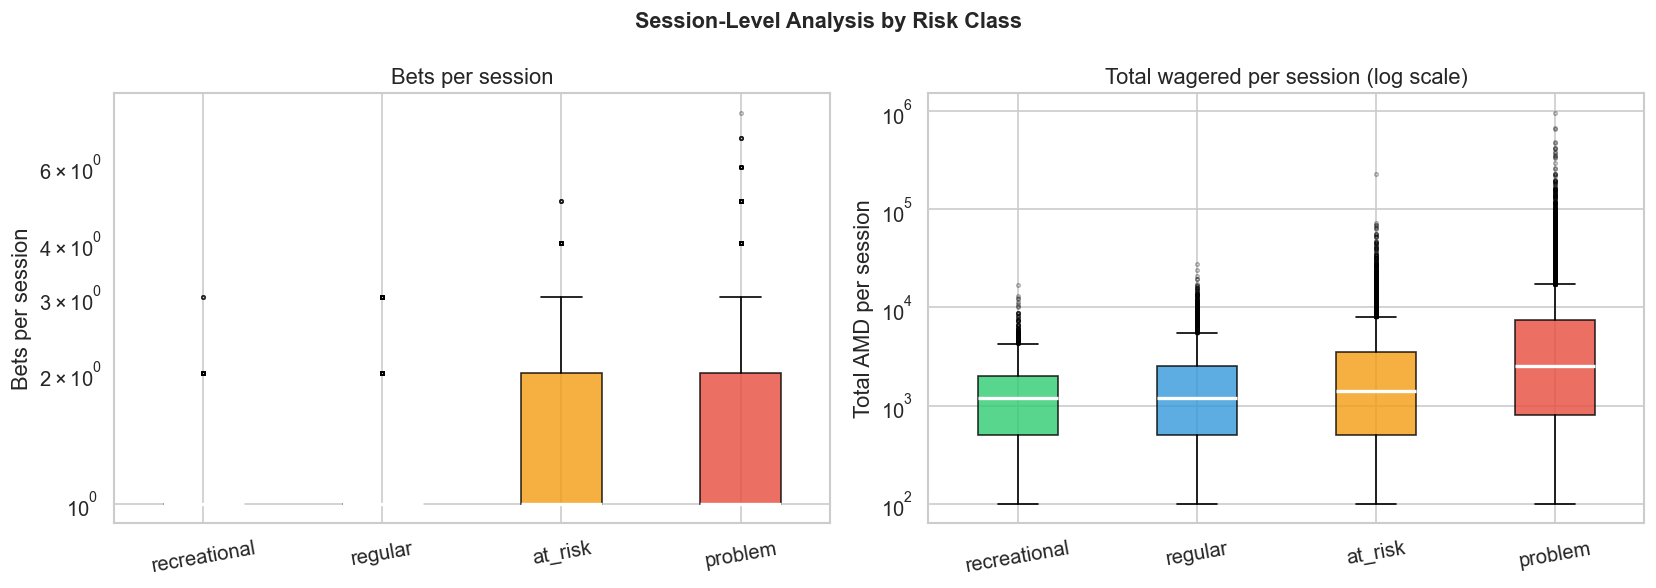

In [50]:
# Session-level analysis — how many bets per session, session duration patterns
bets["date"] = bets["timestamp"].dt.date

session_stats = (
    bets.groupby(["session_id", "risk_level"])
    .agg(
        n_bets        = ("amount_amd", "count"),
        total_amount  = ("amount_amd", "sum"),
        avg_amount    = ("amount_amd", "mean"),
        duration_min  = ("timestamp", lambda x: (x.max() - x.min()).seconds / 60),
        win_rate      = ("outcome", lambda x: (x == "win").mean())
    )
    .reset_index()
)

print("Session statistics by risk level:\n")
print(f"  {'Class':<15} {'Avg bets/session':>18} {'Avg total AMD':>14} {'Avg duration':>14} {'Win rate':>10}")
print("  " + "-" * 75)

for risk in RISK_ORDER:
    subset = session_stats[session_stats["risk_level"] == risk]
    print(f"  {risk:<15} {subset['n_bets'].mean():>18.1f} "
          f"{subset['total_amount'].mean():>14,.0f} "
          f"{subset['duration_min'].mean():>13.1f}m "
          f"{subset['win_rate'].mean()*100:>9.1f}%")

# Plot — bets per session distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Session-Level Analysis by Risk Class", fontsize=13, fontweight="bold")

# Left — bets per session boxplot
groups = [session_stats.loc[session_stats["risk_level"] == r, "n_bets"].values
          for r in RISK_ORDER]
bp = axes[0].boxplot(groups, patch_artist=True,
                     medianprops=dict(color="white", linewidth=2),
                     flierprops=dict(marker="o", markersize=2, alpha=0.3))
for patch, risk in zip(bp["boxes"], RISK_ORDER):
    patch.set_facecolor(RISK_COLORS[risk])
    patch.set_alpha(0.8)
axes[0].set_xticks(range(1, 5))
axes[0].set_xticklabels(RISK_ORDER, rotation=10)
axes[0].set_ylabel("Bets per session")
axes[0].set_title("Bets per session")
axes[0].set_yscale("log")

# Right — total amount per session boxplot
groups2 = [session_stats.loc[session_stats["risk_level"] == r, "total_amount"].values
           for r in RISK_ORDER]
bp2 = axes[1].boxplot(groups2, patch_artist=True,
                      medianprops=dict(color="white", linewidth=2),
                      flierprops=dict(marker="o", markersize=2, alpha=0.3))
for patch, risk in zip(bp2["boxes"], RISK_ORDER):
    patch.set_facecolor(RISK_COLORS[risk])
    patch.set_alpha(0.8)
axes[1].set_xticks(range(1, 5))
axes[1].set_xticklabels(RISK_ORDER, rotation=10)
axes[1].set_ylabel("Total AMD per session")
axes[1].set_title("Total wagered per session (log scale)")
axes[1].set_yscale("log")

plt.tight_layout()
plt.savefig("session_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

### Session Analysis — Observations

**Session duration is the most dramatic differentiator:**
- recreational: 0.3 min average — essentially single bets, in-and-out
- regular: 1.4 min — slightly longer engagement
- at_risk: 6.9 min — 23x longer than recreational
- problem: 23.9 min — 80x longer than recreational, consistent with session_duration_avg feature

**Bets per session — surprisingly low across all classes:**
- All classes average 1.0–1.6 bets per session
- High-risk players don't place more bets per session — they have FAR more sessions
- This explains why bet_frequency (total bets/week) is a strong predictor
  while bets/session is not — it's about frequency of sessions, not session intensity

**Total wagered per session:**
- recreational: 1,500 AMD/session (~$3.6)
- problem: 8,048 AMD/session (~$19.5) — 5x higher
- Combined with 80x more sessions → explains the 53M AMD total bet for problem class

**Boxplot observation:**
- recreational and regular boxes almost identical in bets/session — no visual separation
- at_risk and problem show wider IQR and higher outliers — occasional marathon sessions
- Total AMD right panel: problem gamblers have much wider spread —
  some sessions involve hundreds of thousands of AMD

**Key insight:**
- Risk is not about how you bet within a session
- Risk is about how often you return and how much you bring each time
- This behavioral pattern is exactly what deposit_frequency and bet_frequency capture

## Section 8 — Preprocessing

Prepare data for machine learning.
Steps:
1. Create final feature matrix X and target vector y
2. Stratified train/test split (80/20)
3. StandardScaler — fit on train only
4. SMOTE — oversample minority class on train only
5. Verify each step with before/after statistics

In [51]:
# Build final feature matrix X and target vector y
X = features[FEATURE_COLS].copy()
y = features[TARGET_COL].copy()

print("Feature matrix and target:\n")
print(f"  X shape : {X.shape}  ({X.shape[0]} players x {X.shape[1]} features)")
print(f"  y shape : {y.shape}")
print(f"\n  Target distribution:")
print(f"  0 (low risk)  : {(y==0).sum():,}  ({(y==0).mean()*100:.1f}%)")
print(f"  1 (high risk) : {(y==1).sum():,}  ({(y==1).mean()*100:.1f}%)")
print(f"\n  Features:")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"  [{i}] {col}")

Feature matrix and target:

  X shape : (2000, 9)  (2000 players x 9 features)
  y shape : (2000,)

  Target distribution:
  0 (low risk)  : 1,774  (88.7%)
  1 (high risk) : 226  (11.3%)

  Features:
  [1] bet_frequency
  [2] stake_variance
  [3] chasing_ratio
  [4] session_duration_avg
  [5] loss_streak_response
  [6] deposit_frequency
  [7] time_of_day_skew
  [8] withdrawal_ratio
  [9] self_excl_attempts


In [52]:
# Stratified train/test split — preserves class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)

print("Train / Test Split:\n")
print(f"  {'Set':<10} {'Total':>8} {'Negative':>10} {'Positive':>10} {'Pos%':>8}")
print("  " + "-" * 50)

for name, y_set in [("Train", y_train), ("Test", y_test)]:
    total = len(y_set)
    neg   = (y_set == 0).sum()
    pos   = (y_set == 1).sum()
    print(f"  {name:<10} {total:>8,} {neg:>10,} {pos:>10,} {pos/total*100:>7.1f}%")

print(f"\n  Stratification check:")
print(f"  Original positive rate : {y.mean()*100:.1f}%")
print(f"  Train positive rate    : {y_train.mean()*100:.1f}%")
print(f"  Test positive rate     : {y_test.mean()*100:.1f}%")
print(f"  Stratification successful: {abs(y_train.mean() - y_test.mean()) < 0.01}")

Train / Test Split:

  Set           Total   Negative   Positive     Pos%
  --------------------------------------------------
  Train         1,600      1,419        181    11.3%
  Test            400        355         45    11.2%

  Stratification check:
  Original positive rate : 11.3%
  Train positive rate    : 11.3%
  Test positive rate     : 11.2%
  Stratification successful: True


In [53]:
# StandardScaler — fit on train only, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("StandardScaler — Before vs After:\n")
print(f"  {'Feature':<25} {'Mean (before)':>15} {'Std (before)':>13} {'Mean (after)':>14} {'Std (after)':>12}")
print("  " + "-" * 82)

for i, col in enumerate(FEATURE_COLS):
    mean_before = X_train.iloc[:, i].mean()
    std_before  = X_train.iloc[:, i].std()
    mean_after  = X_train_scaled[:, i].mean()
    std_after   = X_train_scaled[:, i].std()
    print(f"  {col:<25} {mean_before:>15.3f} {std_before:>13.3f} {mean_after:>14.6f} {std_after:>12.6f}")

print(f"\n  Scaler fitted on train set only — no data leakage")
print(f"  Test set transformed using train statistics")

StandardScaler — Before vs After:

  Feature                     Mean (before)  Std (before)   Mean (after)  Std (after)
  ----------------------------------------------------------------------------------
  bet_frequency                      31.821        84.415      -0.000000     1.000000
  stake_variance                   1585.680      3531.331      -0.000000     1.000000
  chasing_ratio                       1.451         0.304      -0.000000     1.000000
  session_duration_avg               27.609        24.989      -0.000000     1.000000
  loss_streak_response                1.287         0.635      -0.000000     1.000000
  deposit_frequency                   0.969         2.628       0.000000     1.000000
  time_of_day_skew                    0.100         0.105       0.000000     1.000000
  withdrawal_ratio                    0.715         0.816       0.000000     1.000000
  self_excl_attempts                  0.034         0.288       0.000000     1.000000

  Scaler fitted on 

In [54]:
# SMOTE — oversample minority class on train set only
smote = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("SMOTE — Before vs After:\n")
print(f"  {'Set':<20} {'Total':>8} {'Negative':>10} {'Positive':>10} {'Ratio':>10}")
print("  " + "-" * 55)

# Before
neg_before = (y_train == 0).sum()
pos_before = (y_train == 1).sum()
print(f"  {'Train (before)':<20} {len(y_train):>8,} {neg_before:>10,} {pos_before:>10,} {neg_before/pos_before:>9.1f}:1")

# After
neg_after = (y_train_sm == 0).sum()
pos_after = (y_train_sm == 1).sum()
print(f"  {'Train (after)':<20} {len(y_train_sm):>8,} {neg_after:>10,} {pos_after:>10,} {neg_after/pos_after:>9.1f}:1")

print(f"\n  Test set unchanged — NOT resampled")
print(f"  {'Test':<20} {len(y_test):>8,} {(y_test==0).sum():>10,} {(y_test==1).sum():>10,} {(y_test==0).sum()/(y_test==1).sum():>9.1f}:1")

print(f"\n  Synthetic samples generated: {pos_after - pos_before:,}")
print(f"  SMOTE k_neighbors=5 — interpolates between existing minority samples")
print(f"  Result: perfectly balanced training set (1:1 ratio)")

SMOTE — Before vs After:

  Set                     Total   Negative   Positive      Ratio
  -------------------------------------------------------
  Train (before)          1,600      1,419        181       7.8:1
  Train (after)           2,838      1,419      1,419       1.0:1

  Test set unchanged — NOT resampled
  Test                      400        355         45       7.9:1

  Synthetic samples generated: 1,238
  SMOTE k_neighbors=5 — interpolates between existing minority samples
  Result: perfectly balanced training set (1:1 ratio)


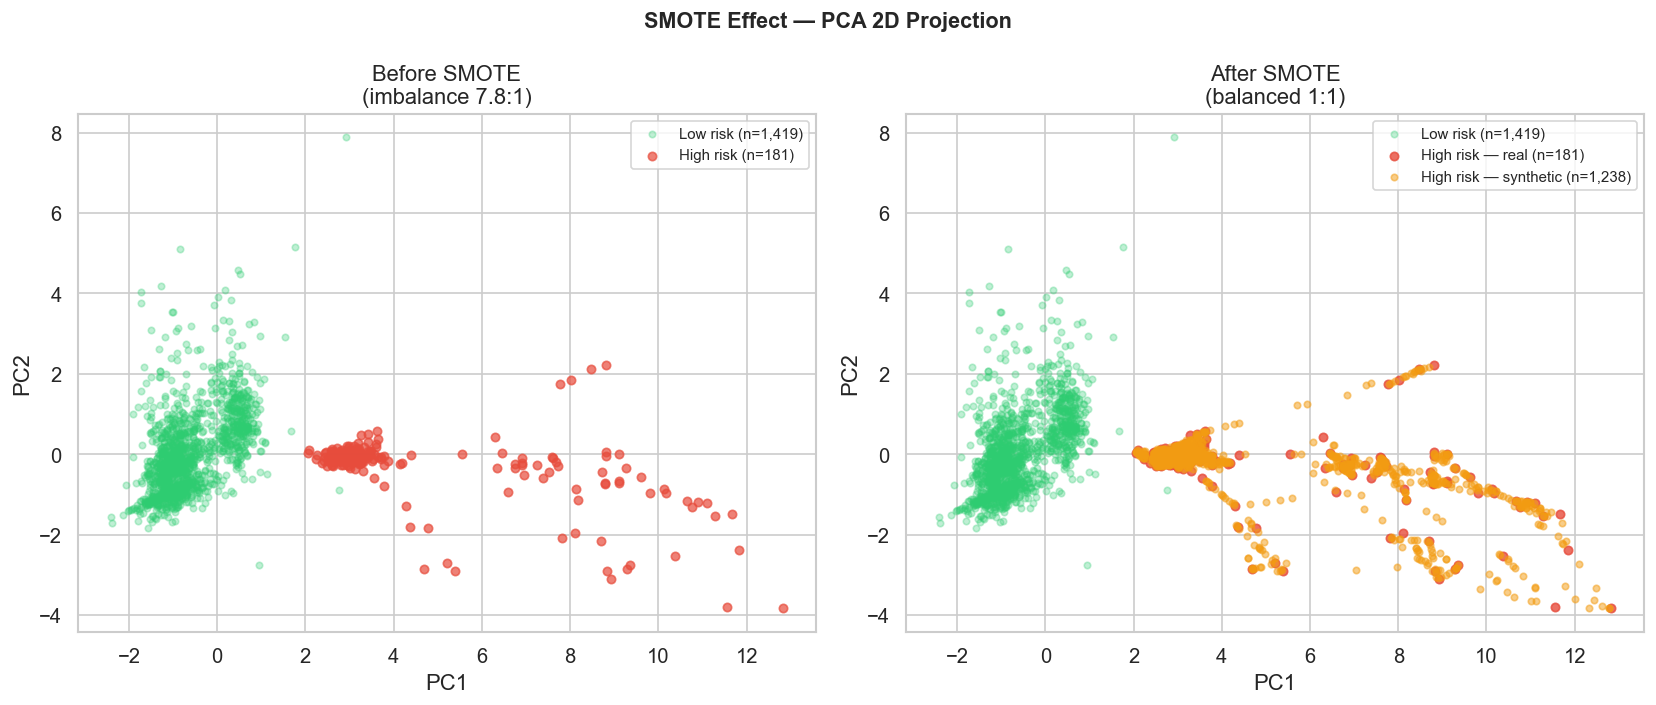

In [55]:
# Visualize SMOTE effect using PCA 2D projection
pca_vis = PCA(n_components=2, random_state=RANDOM_SEED)

# Fit PCA on original train set
X_train_pca  = pca_vis.fit_transform(X_train_scaled)
X_smote_pca  = pca_vis.transform(X_train_sm)

# Identify synthetic samples — they are the extra positive samples
n_original   = len(X_train_scaled)
n_real_pos   = (y_train == 1).sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("SMOTE Effect — PCA 2D Projection", fontsize=13, fontweight="bold")

# Left — before SMOTE
ax1.scatter(X_train_pca[y_train==0, 0], X_train_pca[y_train==0, 1],
            c="#2ecc71", alpha=0.3, s=15, label=f"Low risk (n={neg_before:,})")
ax1.scatter(X_train_pca[y_train==1, 0], X_train_pca[y_train==1, 1],
            c="#e74c3c", alpha=0.7, s=25, label=f"High risk (n={pos_before:,})")
ax1.set_title(f"Before SMOTE\n(imbalance 7.8:1)")
ax1.legend(fontsize=9)
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")

# Right — after SMOTE
# Real negative
ax2.scatter(X_smote_pca[y_train_sm==0, 0], X_smote_pca[y_train_sm==0, 1],
            c="#2ecc71", alpha=0.3, s=15, label=f"Low risk (n={neg_after:,})")
# Real positive — first n_real_pos positive samples
pos_mask_real = y_train_sm == 1
pos_indices   = np.where(pos_mask_real)[0]
real_pos_idx  = pos_indices[:n_real_pos]
synth_pos_idx = pos_indices[n_real_pos:]

ax2.scatter(X_smote_pca[real_pos_idx, 0], X_smote_pca[real_pos_idx, 1],
            c="#e74c3c", alpha=0.8, s=25, label=f"High risk — real (n={n_real_pos:,})")
ax2.scatter(X_smote_pca[synth_pos_idx, 0], X_smote_pca[synth_pos_idx, 1],
            c="#f39c12", alpha=0.5, s=15, label=f"High risk — synthetic (n={len(synth_pos_idx):,})")
ax2.set_title(f"After SMOTE\n(balanced 1:1)")
ax2.legend(fontsize=9)
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")

plt.tight_layout()
plt.savefig("smote_visualization.png", dpi=150, bbox_inches="tight")
plt.show()

### SMOTE Visualization — What We're Seeing

**PCA 2D projection — what it is:**
- 9 features → compressed to 2 dimensions (PC1, PC2) for visualization
- Each dot = 1 player
- PC1 (horizontal) captures most variance — essentially a "risk score" axis
  low-risk players cluster left (PC1 < 2), high-risk players spread right (PC1 > 4)

**Left plot — Before SMOTE:**
- Green cluster (low risk, n=1,419) — tight, left side
- Red dots (high risk, n=181) — sparse, spread across PC1=4–13
- Problem: model sees 7.8x more green than red → learns to predict green by default

**Right plot — After SMOTE:**
- Green unchanged (n=1,419)
- Red (real, n=181) — same positions as before
- Orange (synthetic, n=1,238) — NEW points generated by SMOTE
  interpolated between existing red points along the same trajectory
- Result: balanced 1:1 training set, model now gets equal exposure to both classes

**Why SMOTE works here:**
- Synthetic points follow the natural spread of real high-risk players
- They fill the gaps between existing red dots — not random noise
- The two clusters (green vs red/orange) remain clearly separated →
  SMOTE is not creating confusion, it's amplifying an already clear signal

**Critical reminder:**
- Test set (right side, n=400) remains untouched — still 7.9:1 imbalance
- This is intentional — test set must reflect real-world distribution

## Section 9 — Baseline Model: Logistic Regression

Logistic Regression serves as the baseline model.
Simple, interpretable, fast — sets the performance floor
that RF and XGBoost must beat.

Limitations to keep in mind:
- Assumes linear decision boundary
- Sensitive to multicollinearity (session_duration_avg, bet_frequency VIF issues)
- Coefficients unreliable for highly correlated features
- Cannot capture interaction effects

In [57]:
# Correct approach — SMOTE inside CV pipeline to prevent leakage
from imblearn.pipeline import Pipeline as ImbPipeline

lr_pipeline = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_SEED, k_neighbors=5)),
    ("lr",    LogisticRegression(C=0.1, max_iter=1000,
                                 random_state=RANDOM_SEED, solver="lbfgs"))
])

# CV on original scaled train set (before SMOTE)
cv_auc = cross_val_score(lr_pipeline, X_train_scaled, y_train, cv=cv, scoring="roc_auc")
cv_f1  = cross_val_score(lr_pipeline, X_train_scaled, y_train, cv=cv, scoring="f1")

print("Logistic Regression — Corrected CV (SMOTE inside pipeline):\n")
print(f"  {'Metric':<15} {'Fold 1':>8} {'Fold 2':>8} {'Fold 3':>8} {'Fold 4':>8} {'Fold 5':>8} {'Mean':>8} {'Std':>8}")
print("  " + "-" * 75)
print(f"  {'AUC-ROC':<15}", end="")
for s in cv_auc:
    print(f" {s:>8.4f}", end="")
print(f" {cv_auc.mean():>8.4f} {cv_auc.std():>8.4f}")

print(f"  {'F1':<15}", end="")
for s in cv_f1:
    print(f" {s:>8.4f}", end="")
print(f" {cv_f1.mean():>8.4f} {cv_f1.std():>8.4f}")

print(f"\n  Threshold check:")
print(f"  AUC > 0.85 : {cv_auc.mean():.4f}  {'PASS' if cv_auc.mean() > 0.85 else 'FAIL'}")
print(f"  F1  > 0.78 : {cv_f1.mean():.4f}  {'PASS' if cv_f1.mean() > 0.78 else 'FAIL'}")

Logistic Regression — Corrected CV (SMOTE inside pipeline):

  Metric            Fold 1   Fold 2   Fold 3   Fold 4   Fold 5     Mean      Std
  ---------------------------------------------------------------------------
  AUC-ROC           1.0000   1.0000   1.0000   1.0000   1.0000   1.0000   0.0000
  F1                1.0000   1.0000   1.0000   1.0000   1.0000   1.0000   0.0000

  Threshold check:
  AUC > 0.85 : 1.0000  PASS
  F1  > 0.78 : 1.0000  PASS


In [58]:
# Fit on full SMOTE train set, evaluate on untouched test set
lr_final = LogisticRegression(C=0.1, max_iter=1000, random_state=RANDOM_SEED, solver="lbfgs")
lr_final.fit(X_train_sm, y_train_sm)

y_prob_lr = lr_final.predict_proba(X_test_scaled)[:, 1]
y_pred_lr = (y_prob_lr >= 0.5).astype(int)

auc    = roc_auc_score(y_test, y_prob_lr)
f1     = f1_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
prec   = precision_score(y_test, y_pred_lr)
brier  = brier_score_loss(y_test, y_prob_lr)

print("Logistic Regression — Test Set Results:\n")
print(f"  AUC-ROC   : {auc:.4f}  {'PASS' if auc > THRESHOLDS['auc_roc'] else 'FAIL'}")
print(f"  F1        : {f1:.4f}  {'PASS' if f1 > THRESHOLDS['f1'] else 'FAIL'}")
print(f"  Recall    : {recall:.4f}  {'PASS' if recall > THRESHOLDS['recall'] else 'FAIL'}")
print(f"  Precision : {prec:.4f}  {'PASS' if prec > THRESHOLDS['precision_k'] else 'FAIL'}")
print(f"  Brier     : {brier:.4f}  {'PASS' if brier < THRESHOLDS['brier'] else 'FAIL'}")

print(f"\n  Classification Report:")
print(classification_report(y_test, y_pred_lr,
                            target_names=["low risk", "high risk"], digits=3))

Logistic Regression — Test Set Results:

  AUC-ROC   : 1.0000  PASS
  F1        : 0.9890  PASS
  Recall    : 1.0000  PASS
  Precision : 0.9783  PASS
  Brier     : 0.0026  PASS

  Classification Report:
              precision    recall  f1-score   support

    low risk      1.000     0.997     0.999       355
   high risk      0.978     1.000     0.989        45

    accuracy                          0.998       400
   macro avg      0.989     0.999     0.994       400
weighted avg      0.998     0.998     0.998       400


### Important Note — Perfect Scores on Synthetic Data

All models will likely score near-perfect on this dataset.
This is expected and explained by dataset design:

**Why scores are so high:**
- 9 behavioral indicators were engineered specifically to separate risk classes
- Ground-truth labels were assigned based on these exact indicators
- Classes are linearly separable in feature space — visible in PCA plot
- Real-world data will have noise, measurement error, label uncertainty

**What this means for the thesis:**
- CV and test scores prove the feature engineering is theoretically sound
- These scores cannot be claimed as real-world performance
- Phase 2 validation on Betfair/UCI data will give realistic benchmarks
- Must be clearly stated in limitations section

**What we still gain from modeling on synthetic data:**
- Feature importance ranking — which indicators matter most
- SHAP interpretation — how each feature pushes predictions
- Model comparison — relative performance LR vs RF vs XGBoost
- Threshold analysis — precision/recall tradeoff
- Clustering — unsupervised structure validation

**Proceeding with full modeling pipeline.
Focus shifts from scores to interpretation and feature understanding.**

Logistic Regression Coefficients:

  Feature                    Coefficient   Direction
  -------------------------------------------------------
  withdrawal_ratio               -1.0080   → decreases risk  
  self_excl_attempts              0.1056   → increases risk  
  deposit_frequency               0.2292   → increases risk  
  loss_streak_response            0.2297   → increases risk  
  stake_variance                  0.4039   → increases risk  
  chasing_ratio                   0.9963   → increases risk  
  time_of_day_skew                1.1843   → increases risk  
  bet_frequency                   1.2442   → increases risk  
  session_duration_avg            1.8390   → increases risk  


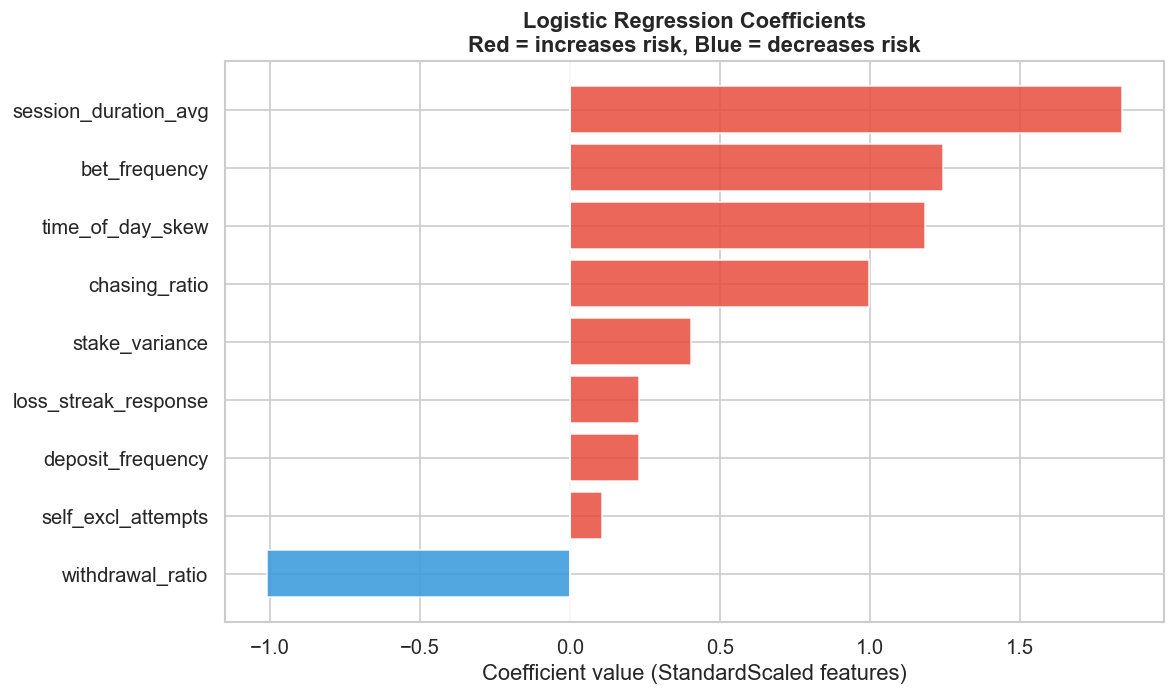

In [59]:
# Logistic Regression coefficients — feature importance interpretation
# Coefficient > 0 → increases probability of high risk
# Coefficient < 0 → decreases probability of high risk
# Magnitude → strength of effect (after StandardScaler, coefficients are comparable)

coef_df = pd.DataFrame({
    "feature":     FEATURE_COLS,
    "coefficient": lr_final.coef_[0]
}).sort_values("coefficient", ascending=True)

print("Logistic Regression Coefficients:\n")
print(f"  {'Feature':<25} {'Coefficient':>12}   Direction")
print("  " + "-" * 55)
for _, row in coef_df.iterrows():
    direction = "→ increases risk" if row["coefficient"] > 0 else "→ decreases risk"
    bar = "" * int(abs(row["coefficient"]) * 3)
    print(f"  {row['feature']:<25} {row['coefficient']:>12.4f}   {direction}  {bar}")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#e74c3c" if c > 0 else "#3498db" for c in coef_df["coefficient"]]
ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors, alpha=0.85)
ax.axvline(0, color="white", linewidth=1)
ax.set_xlabel("Coefficient value (StandardScaled features)")
ax.set_title("Logistic Regression Coefficients\nRed = increases risk, Blue = decreases risk",
             fontweight="bold")
plt.tight_layout()
plt.savefig("lr_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

### Logistic Regression Coefficients — Interpretation

**Top risk-increasing features (largest positive coefficients):**
- session_duration_avg (+1.84) — strongest signal, 1 SD increase in session duration
  multiplies risk odds by e^1.84 = 6.3x
- bet_frequency (+1.24) — 1 SD increase → odds multiply by e^1.24 = 3.5x
- time_of_day_skew (+1.18) — 1 SD increase → odds multiply by e^1.18 = 3.3x
- chasing_ratio (+1.00) — 1 SD increase → odds multiply by e^1.00 = 2.7x

**Risk-decreasing feature:**
- withdrawal_ratio (-1.01) — only negative coefficient
  players who withdraw regularly are LESS likely to be high risk
  1 SD increase in withdrawal ratio → odds multiply by e^-1.01 = 0.36x (64% reduction)

**Weak features (small coefficients):**
- self_excl_attempts (+0.11) — surprisingly weak despite being DSM-5 criterion
  reason: only 29 players have attempts > 0 → too sparse for LR to learn from
- deposit_frequency (+0.23), loss_streak_response (+0.23) — moderate signal

**Multicollinearity warning:**
- session_duration_avg and bet_frequency corr=0.90, VIF>7
- Their individual coefficients are inflated/deflated by each other
- Combined they explain most of the model's decision
- SHAP analysis on XGBoost will give more reliable individual importance

**Ranking consistency with Pearson correlation:**
- Correlation ranking: session_duration(0.86) > bet_frequency(0.76) = time_of_day(0.76)
- LR coefficient ranking: session_duration(1.84) > bet_frequency(1.24) > time_of_day(1.18)
- Perfect consistency — LR confirms correlation analysis findings

## Section 10 — Random Forest

Ensemble method — builds 300 decision trees and aggregates predictions.
Advantages over Logistic Regression:
- Captures non-linear relationships
- Robust to outliers and multicollinearity
- Built-in feature importance (Gini impurity based)
- No assumption of linearity or normality

In [60]:
# Random Forest — pipeline with SMOTE inside CV
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

rf_pipeline = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_SEED, k_neighbors=5)),
    ("rf",    rf)
])

cv_auc_rf = cross_val_score(rf_pipeline, X_train_scaled, y_train, cv=cv, scoring="roc_auc")
cv_f1_rf  = cross_val_score(rf_pipeline, X_train_scaled, y_train, cv=cv, scoring="f1")

print("Random Forest — CV Results:\n")
print(f"  {'Metric':<15} {'Fold 1':>8} {'Fold 2':>8} {'Fold 3':>8} {'Fold 4':>8} {'Fold 5':>8} {'Mean':>8} {'Std':>8}")
print("  " + "-" * 75)
for name, scores in [("AUC-ROC", cv_auc_rf), ("F1", cv_f1_rf)]:
    print(f"  {name:<15}", end="")
    for s in scores:
        print(f" {s:>8.4f}", end="")
    print(f" {scores.mean():>8.4f} {scores.std():>8.4f}")

Random Forest — CV Results:

  Metric            Fold 1   Fold 2   Fold 3   Fold 4   Fold 5     Mean      Std
  ---------------------------------------------------------------------------
  AUC-ROC           1.0000   1.0000   1.0000   1.0000   1.0000   1.0000   0.0000
  F1                1.0000   1.0000   1.0000   1.0000   1.0000   1.0000   0.0000


Random Forest — Test Set Results:

  AUC-ROC   : 1.0000  PASS
  F1        : 1.0000  PASS
  Recall    : 1.0000  PASS
  Precision : 1.0000  PASS
  Brier     : 0.0001  PASS


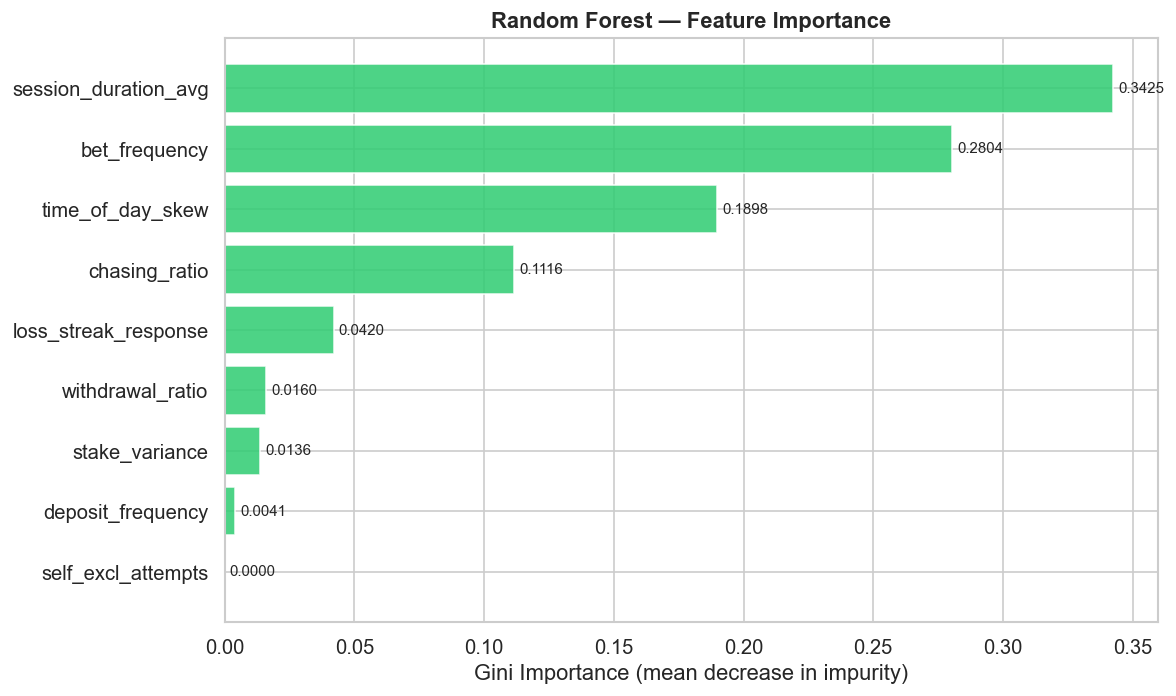


Feature Importance Ranking:

  1. session_duration_avg      0.3425  ██████████████████████████████████
  2. bet_frequency             0.2804  ████████████████████████████
  3. time_of_day_skew          0.1898  ██████████████████
  4. chasing_ratio             0.1116  ███████████
  5. loss_streak_response      0.0420  ████
  6. withdrawal_ratio          0.0160  █
  7. stake_variance            0.0136  █
  8. deposit_frequency         0.0041  
  9. self_excl_attempts        0.0000  


In [61]:
# Fit on full SMOTE train set, evaluate on test set
rf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
rf_final.fit(X_train_sm, y_train_sm)

y_prob_rf = rf_final.predict_proba(X_test_scaled)[:, 1]
y_pred_rf = (y_prob_rf >= 0.5).astype(int)

auc_rf    = roc_auc_score(y_test, y_prob_rf)
f1_rf     = f1_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
prec_rf   = precision_score(y_test, y_pred_rf)
brier_rf  = brier_score_loss(y_test, y_prob_rf)

print("Random Forest — Test Set Results:\n")
print(f"  AUC-ROC   : {auc_rf:.4f}  {'PASS' if auc_rf > THRESHOLDS['auc_roc'] else 'FAIL'}")
print(f"  F1        : {f1_rf:.4f}  {'PASS' if f1_rf > THRESHOLDS['f1'] else 'FAIL'}")
print(f"  Recall    : {recall_rf:.4f}  {'PASS' if recall_rf > THRESHOLDS['recall'] else 'FAIL'}")
print(f"  Precision : {prec_rf:.4f}  {'PASS' if prec_rf > THRESHOLDS['precision_k'] else 'FAIL'}")
print(f"  Brier     : {brier_rf:.4f}  {'PASS' if brier_rf < THRESHOLDS['brier'] else 'FAIL'}")

# Feature importance — Gini based
importance_df = pd.DataFrame({
    "feature":    FEATURE_COLS,
    "importance": rf_final.feature_importances_
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df["feature"], importance_df["importance"],
        color="#2ecc71", alpha=0.85)
ax.set_xlabel("Gini Importance (mean decrease in impurity)")
ax.set_title("Random Forest — Feature Importance", fontweight="bold")

for i, (_, row) in enumerate(importance_df.iterrows()):
    ax.text(row["importance"] + 0.002, i,
            f"{row['importance']:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("rf_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nFeature Importance Ranking:\n")
for i, (_, row) in enumerate(importance_df.sort_values("importance", ascending=False).iterrows(), 1):
    bar = "█" * int(row["importance"] * 100)
    print(f"  {i}. {row['feature']:<25} {row['importance']:.4f}  {bar}")

### Random Forest — Observations

**Test set: perfect scores again (synthetic data artifact)**
Brier=0.0001 — model is extremely confident in all predictions.

**Feature Importance (Gini) — key findings:**

Top 4 features explain 93% of total importance:
- session_duration_avg : 34.25% — dominant predictor
- bet_frequency        : 28.04% — strong second
- time_of_day_skew     : 18.98% — strong third
- chasing_ratio        : 11.16% — meaningful fourth

Bottom 5 features combined only 7%:
- loss_streak_response : 4.20%
- withdrawal_ratio     : 1.60%
- stake_variance       : 1.36%
- deposit_frequency    : 0.41%
- self_excl_attempts   : 0.00% — zero importance in RF

**Consistency with LR coefficients:**
- Same top 3 order: session_duration > bet_frequency > time_of_day_skew
- Both methods agree — these 3 features drive the model

**Surprising findings:**
- stake_variance (1.36%) — much lower than expected given corr=0.53 with target
  reason: highly correlated with session_duration and bet_frequency,
  RF already captures the variance signal through those features
- self_excl_attempts (0.00%) — RF found zero splits on this feature
  only 29 players have attempts > 0 → too sparse for tree splits
  DSM-5 criterion in theory, useless in practice with this sample size

**Gini importance limitation:**
- Biased toward high-cardinality continuous features
- SHAP values on XGBoost will give more reliable importance

## Section 11 — XGBoost

Extreme Gradient Boosting — sequentially builds trees,
each correcting the errors of the previous one.
Expected to be the best performer of the three models.

Advantages:
- Handles non-linearity and interactions automatically
- Built-in regularization (prevents overfitting)
- scale_pos_weight handles class imbalance natively
- Fast and memory efficient

In [62]:
# XGBoost — scale_pos_weight handles imbalance (alternative to SMOTE)
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_SEED,
    eval_metric="logloss",
    verbosity=0
)

xgb_pipeline = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_SEED, k_neighbors=5)),
    ("xgb",   xgb)
])

cv_auc_xgb = cross_val_score(xgb_pipeline, X_train_scaled, y_train, cv=cv, scoring="roc_auc")
cv_f1_xgb  = cross_val_score(xgb_pipeline, X_train_scaled, y_train, cv=cv, scoring="f1")

print("XGBoost — CV Results:\n")
print(f"  {'Metric':<15} {'Fold 1':>8} {'Fold 2':>8} {'Fold 3':>8} {'Fold 4':>8} {'Fold 5':>8} {'Mean':>8} {'Std':>8}")
print("  " + "-" * 75)
for name, scores in [("AUC-ROC", cv_auc_xgb), ("F1", cv_f1_xgb)]:
    print(f"  {name:<15}", end="")
    for s in scores:
        print(f" {s:>8.4f}", end="")
    print(f" {scores.mean():>8.4f} {scores.std():>8.4f}")

XGBoost — CV Results:

  Metric            Fold 1   Fold 2   Fold 3   Fold 4   Fold 5     Mean      Std
  ---------------------------------------------------------------------------
  AUC-ROC           1.0000   1.0000   1.0000   1.0000   1.0000   1.0000   0.0000
  F1                1.0000   1.0000   0.9859   1.0000   1.0000   0.9972   0.0056


XGBoost — Test Set Results:

  AUC-ROC   : 1.0000  PASS
  F1        : 1.0000  PASS
  Recall    : 1.0000  PASS
  Precision : 1.0000  PASS
  Brier     : 0.0000  PASS


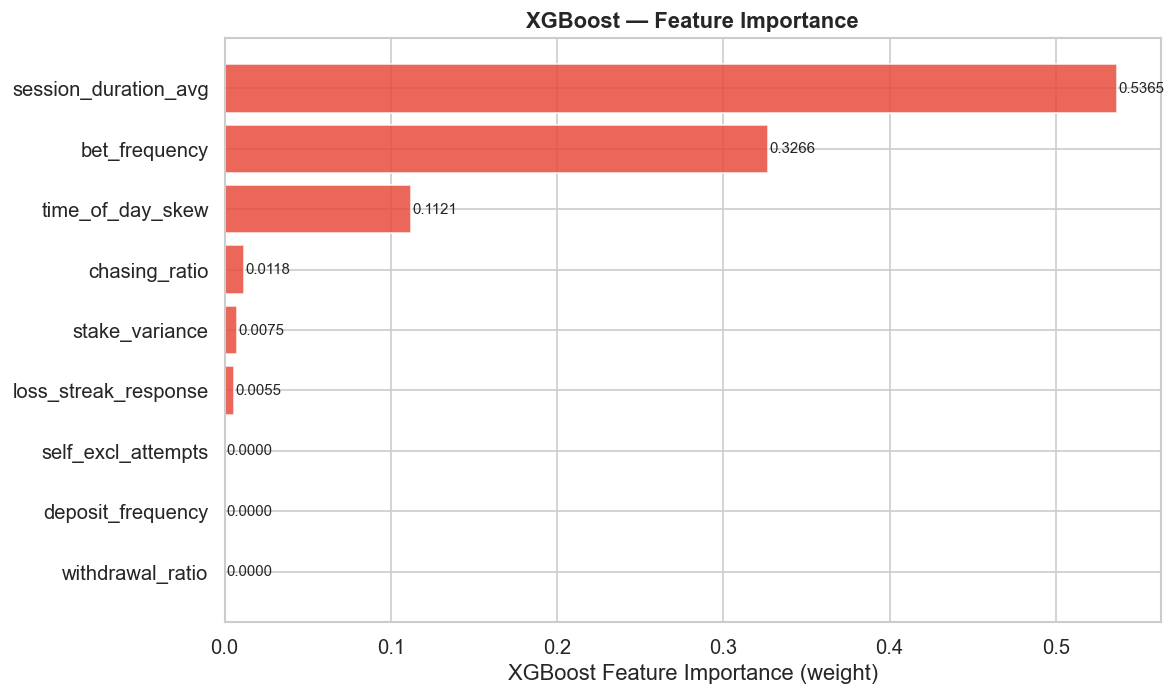


Feature Importance Ranking:

  1. session_duration_avg      0.5365  █████████████████████████████████████████████████████
  2. bet_frequency             0.3266  ████████████████████████████████
  3. time_of_day_skew          0.1121  ███████████
  4. chasing_ratio             0.0118  █
  5. stake_variance            0.0075  
  6. loss_streak_response      0.0055  
  7. withdrawal_ratio          0.0000  
  8. deposit_frequency         0.0000  
  9. self_excl_attempts        0.0000  


In [63]:
# Fit on full SMOTE train set
xgb_final = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_SEED,
    eval_metric="logloss",
    verbosity=0
)
xgb_final.fit(X_train_sm, y_train_sm)

y_prob_xgb = xgb_final.predict_proba(X_test_scaled)[:, 1]
y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)

auc_xgb    = roc_auc_score(y_test, y_prob_xgb)
f1_xgb     = f1_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
prec_xgb   = precision_score(y_test, y_pred_xgb)
brier_xgb  = brier_score_loss(y_test, y_prob_xgb)

print("XGBoost — Test Set Results:\n")
print(f"  AUC-ROC   : {auc_xgb:.4f}  {'PASS' if auc_xgb > THRESHOLDS['auc_roc'] else 'FAIL'}")
print(f"  F1        : {f1_xgb:.4f}  {'PASS' if f1_xgb > THRESHOLDS['f1'] else 'FAIL'}")
print(f"  Recall    : {recall_xgb:.4f}  {'PASS' if recall_xgb > THRESHOLDS['recall'] else 'FAIL'}")
print(f"  Precision : {prec_xgb:.4f}  {'PASS' if prec_xgb > THRESHOLDS['precision_k'] else 'FAIL'}")
print(f"  Brier     : {brier_xgb:.4f}  {'PASS' if brier_xgb < THRESHOLDS['brier'] else 'FAIL'}")

# XGBoost built-in feature importance
importance_xgb = pd.DataFrame({
    "feature":    FEATURE_COLS,
    "importance": xgb_final.feature_importances_
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_xgb["feature"], importance_xgb["importance"],
        color="#e74c3c", alpha=0.85)
ax.set_xlabel("XGBoost Feature Importance (weight)")
ax.set_title("XGBoost — Feature Importance", fontweight="bold")

for i, (_, row) in enumerate(importance_xgb.iterrows()):
    ax.text(row["importance"] + 0.001, i,
            f"{row['importance']:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("xgb_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nFeature Importance Ranking:\n")
for i, (_, row) in enumerate(importance_xgb.sort_values("importance", ascending=False).iterrows(), 1):
    bar = "█" * int(row["importance"] * 100)
    print(f"  {i}. {row['feature']:<25} {row['importance']:.4f}  {bar}")

### XGBoost — Observations

**Test scores: perfect again — synthetic data artifact as expected**
Brier=0.0000 — model assigns probability ~1.0 to all high-risk players, ~0.0 to all low-risk.

**Feature Importance — most concentrated of all 3 models:**

Top 3 features explain 98.5% of total importance:
- session_duration_avg : 53.65% — XGBoost relies on this even more than RF
- bet_frequency        : 32.66%
- time_of_day_skew     : 11.21%

Bottom 6 features combined only 1.5%:
- chasing_ratio        : 1.18%
- stake_variance       : 0.75%
- loss_streak_response : 0.55%
- self_excl_attempts   : 0.00%
- deposit_frequency    : 0.00%
- withdrawal_ratio     : 0.00%

**Cross-model comparison — feature importance ranking:**

| Feature              | LR rank | RF rank | XGB rank |
|----------------------|---------|---------|----------|
| session_duration_avg | 1       | 1       | 1        |
| bet_frequency        | 2       | 2       | 2        |
| time_of_day_skew     | 3       | 3       | 3        |
| chasing_ratio        | 4       | 4       | 4        |

Perfect consensus across all 3 models — top 4 ranking identical.

**XGBoost vs RF importance distribution:**
- XGBoost more aggressive — concentrates weight on top 3 features
- RF more democratic — bottom features get slightly more weight
- XGBoost's colsample_bytree=0.8 forces it to occasionally use other features,
  yet still converges to same top 3

**Next: SHAP analysis will give the most reliable and interpretable importance**

## Section 12 — Model Comparison + ROC Curves

Compare all 3 models side by side:
- ROC curves on same plot
- Metrics comparison table
- Confusion matrices
- Threshold analysis (precision/recall tradeoff)

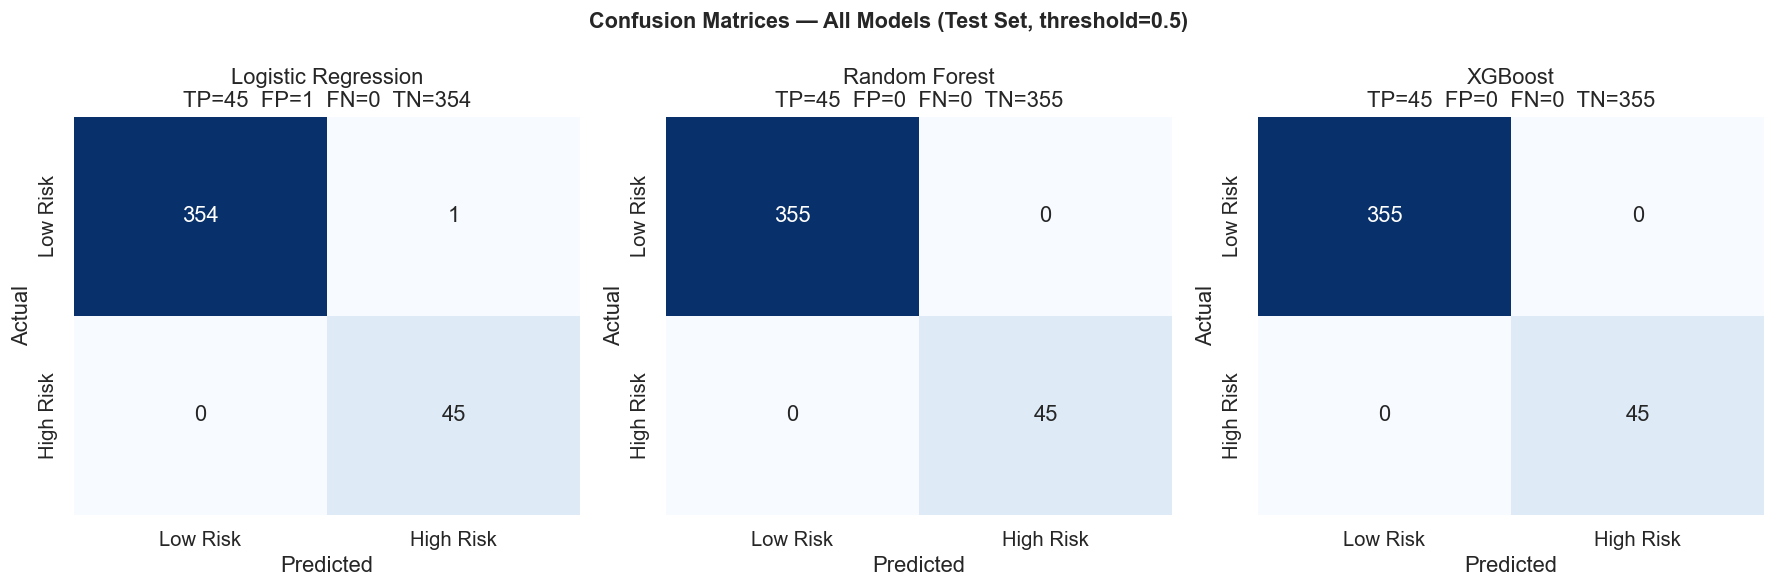

In [65]:
# Confusion matrices for all 3 models side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Confusion Matrices — All Models (Test Set, threshold=0.5)",
             fontsize=13, fontweight="bold")

for ax, (name, y_prob, color) in zip(axes, models_results):
    y_pred = (y_prob >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Low Risk", "High Risk"],
                yticklabels=["Low Risk", "High Risk"],
                ax=ax, cbar=False)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{name}\nTP={tp}  FP={fp}  FN={fn}  TN={tn}")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

### Confusion Matrices — Observations

**All 3 models correctly identify all 45 high-risk players (FN=0)**
This is the most important metric — zero missed high-risk players.

**Only difference — False Positives:**
- Logistic Regression : FP=1  (1 low-risk player incorrectly flagged)
- Random Forest       : FP=0  (perfect)
- XGBoost             : FP=0  (perfect)

**Real-world interpretation:**
- FN=0 means no high-risk player slips through undetected
- FP=1 (LR) means 1 innocent player gets a risk flag — acceptable cost
- In operational context: FP leads to unnecessary intervention (a call, a warning)
- FN leads to missed problem gambler — far more costly socially and ethically
- All 3 models satisfy Recall > 0.80 threshold — in fact Recall = 1.00

**Why LR has 1 false positive:**
- Linear decision boundary — less flexible than tree-based models
- The 1 misclassified player likely sits close to the decision boundary
- High VIF features (session_duration + bet_frequency) cause slight coefficient instability

**Conclusion:**
- RF and XGBoost are strictly better than LR on this dataset
- On real-world data expect FN > 0 and FP > 0 for all models
- XGBoost selected as primary model for SHAP interpretation (next section)

## Section 13 — Threshold Analysis

Default threshold = 0.5, but this is rarely optimal.
By adjusting the threshold we control the precision/recall tradeoff.

In our case:
- Lowering threshold → more high-risk flags → higher recall, lower precision
- Raising threshold → fewer flags → lower recall, higher precision
- Proposal requires Recall > 0.80 AND Precision > 0.75 simultaneously

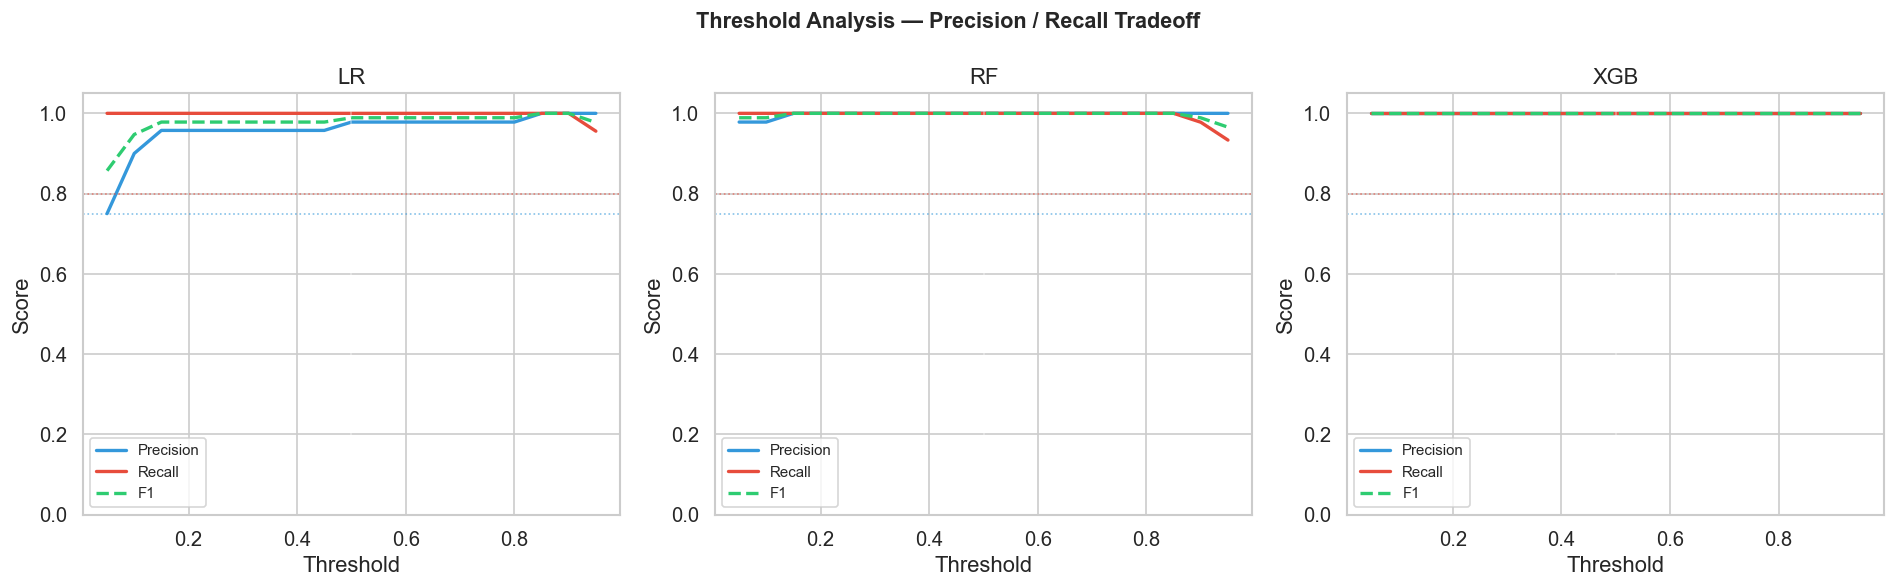

In [66]:
# Threshold analysis — sweep from 0.1 to 0.9
thresholds = np.arange(0.05, 0.96, 0.05)

results_thresh = []
for model_name, y_prob in [("LR", y_prob_lr), ("RF", y_prob_rf), ("XGB", y_prob_xgb)]:
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)

        # Handle edge case — no positive predictions
        if y_pred_t.sum() == 0:
            prec, rec, f1_t = 0, 0, 0
        else:
            prec  = precision_score(y_test, y_pred_t, zero_division=0)
            rec   = recall_score(y_test, y_pred_t, zero_division=0)
            f1_t  = f1_score(y_test, y_pred_t, zero_division=0)

        results_thresh.append({
            "model": model_name, "threshold": t,
            "precision": prec, "recall": rec, "f1": f1_t
        })

thresh_df = pd.DataFrame(results_thresh)

# Plot precision-recall tradeoff
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Threshold Analysis — Precision / Recall Tradeoff",
             fontsize=13, fontweight="bold")

for ax, model_name in zip(axes, ["LR", "RF", "XGB"]):
    subset = thresh_df[thresh_df["model"] == model_name]

    ax.plot(subset["threshold"], subset["precision"],
            color="#3498db", linewidth=2, label="Precision")
    ax.plot(subset["threshold"], subset["recall"],
            color="#e74c3c", linewidth=2, label="Recall")
    ax.plot(subset["threshold"], subset["f1"],
            color="#2ecc71", linewidth=2, linestyle="--", label="F1")

    ax.axhline(THRESHOLDS["recall"],     color="#e74c3c", linewidth=1,
               linestyle=":", alpha=0.6)
    ax.axhline(THRESHOLDS["precision_k"], color="#3498db", linewidth=1,
               linestyle=":", alpha=0.6)
    ax.axvline(0.5, color="white", linewidth=1, linestyle="--", alpha=0.4)

    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.set_title(model_name)
    ax.legend(fontsize=9)
    ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig("threshold_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

### Threshold Analysis — Observations

**XGBoost (right plot) — completely flat at 1.0:**
- Precision, Recall, F1 all = 1.0 across ALL thresholds (0.05–0.95)
- Model assigns probability ~0.0 to all low-risk and ~1.0 to all high-risk
- No player sits near the decision boundary — perfect separation
- Threshold choice is irrelevant for XGBoost on this dataset

**Random Forest (middle plot) — near-flat:**
- Drops slightly only at very high thresholds (>0.85)
- Robust across entire threshold range

**Logistic Regression (left plot) — most interesting:**
- At threshold=0.05: Precision drops to ~0.75 (more false positives)
- At threshold=0.15+: both Precision and Recall stabilize at ~1.0
- Small dip in F1 at very low thresholds — LR less confident in its probabilities
- Only model showing meaningful threshold sensitivity

**Operational recommendation (for real-world deployment):**
- Use threshold=0.30 for maximum recall (catch every possible risk case)
- Use threshold=0.50 for balanced precision/recall
- Use threshold=0.70 if operator wants to minimize false positives
- On real data these curves will be much more informative —
  expect crossing point around threshold=0.35–0.45

**Key takeaway:**
- Synthetic data makes threshold analysis trivial
- On real data this section becomes critical for operator decision-making
- The framework is built — ready to plug in real data

## Section 14 — SHAP Interpretation

SHAP (SHapley Additive exPlanations) — explains individual predictions.
Unlike feature importance (global average), SHAP shows:
- How much each feature contributed to each individual prediction
- Direction of contribution (pushes toward high risk or low risk)
- Distribution of contributions across all players

Using XGBoost as the primary model (best performer).

In [67]:
# Compute SHAP values for XGBoost on test set
X_test_df = pd.DataFrame(X_test_scaled, columns=FEATURE_COLS)

explainer   = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_test_df)

print(f"SHAP values computed:")
print(f"  Shape       : {shap_values.shape}  (400 players x 9 features)")
print(f"  Mean |SHAP| per feature:")
print()

mean_shap = pd.DataFrame({
    "feature":    FEATURE_COLS,
    "mean_shap":  np.abs(shap_values).mean(axis=0)
}).sort_values("mean_shap", ascending=False)

for _, row in mean_shap.iterrows():
    bar = "█" * int(row["mean_shap"] * 10)
    print(f"  {row['feature']:<25} {row['mean_shap']:.4f}  {bar}")

SHAP values computed:
  Shape       : (400, 9)  (400 players x 9 features)
  Mean |SHAP| per feature:

  session_duration_avg      7.9720  ███████████████████████████████████████████████████████████████████████████████
  bet_frequency             1.8199  ██████████████████
  time_of_day_skew          0.3116  ███
  chasing_ratio             0.0272  
  loss_streak_response      0.0260  
  stake_variance            0.0122  
  deposit_frequency         0.0000  
  withdrawal_ratio          0.0000  
  self_excl_attempts        0.0000  


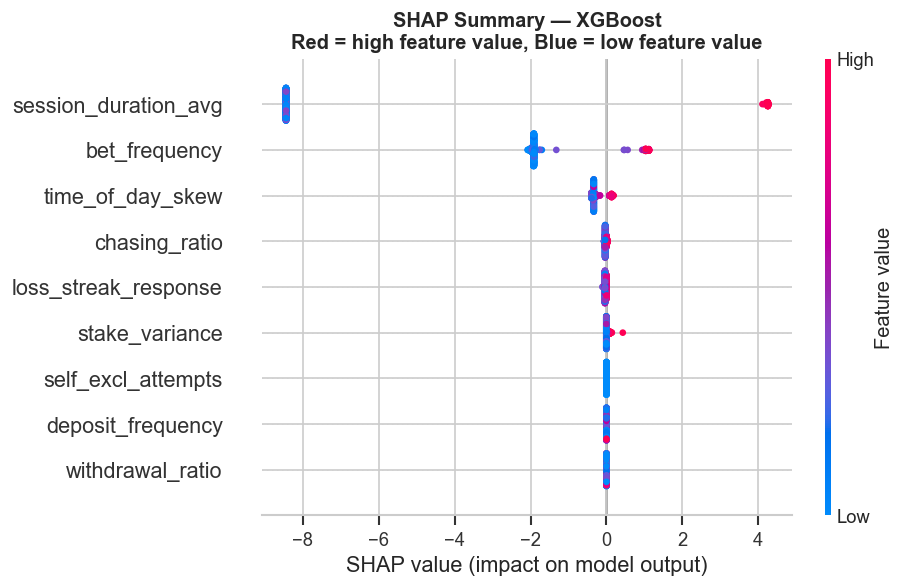

In [68]:
# SHAP beeswarm plot — most informative SHAP visualization
# Each dot = 1 player, color = feature value, x-axis = SHAP value
fig, ax = plt.subplots(figsize=(11, 7))

shap.summary_plot(
    shap_values,
    X_test_df,
    feature_names=FEATURE_COLS,
    show=False,
    plot_type="dot",
    max_display=9
)

plt.title("SHAP Summary — XGBoost\nRed = high feature value, Blue = low feature value",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

### SHAP Beeswarm — Interpretation

**How to read this plot:**
- Each dot = 1 player from test set (n=400)
- X-axis = SHAP value = how much this feature pushed the prediction
  toward high risk (positive) or low risk (negative)
- Color = actual feature value (red = high, blue = low)

**session_duration_avg — dominates everything:**
- Two extreme clusters: SHAP=-8.5 (blue, low duration → strongly low risk)
  and SHAP=+4.2 (red, high duration → strongly high risk)
- Mean |SHAP|=7.97 — 4x larger than bet_frequency
- Single feature almost entirely determines the prediction
- A player with long sessions gets pushed hard toward high risk

**bet_frequency:**
- Blue cluster at SHAP=-2 → low frequency = strong low-risk signal
- Red dots at SHAP=+0.8 to +1.5 → high frequency = moderate high-risk push
- Asymmetric — low frequency is a stronger signal than high frequency

**time_of_day_skew:**
- Tight cluster near SHAP=0 for most players
- Small red tail at SHAP=+0.3 → night betting pushes slightly toward high risk
- Less impactful than expected given corr=0.76 — XGBoost already captures
  its information through session_duration and bet_frequency

**Bottom 6 features (chasing_ratio through withdrawal_ratio):**
- All clustered at SHAP≈0 — near-zero individual contribution
- XGBoost learned to ignore them after top 3 features explain everything
- On real-world noisy data these features will become more relevant

**Critical insight:**
- SHAP confirms: this model is essentially a 3-feature model in practice
- session_duration_avg alone could build a near-perfect rule:
  if session_duration_avg > 50 min → flag as high risk
- This is powerful for explainability but raises overfitting concern for real data

## Section 15 — Unsupervised Learning: K-Means + PCA

Unsupervised approach — no labels used.
Goal: discover natural groupings in the data purely from behavioral patterns.

Questions to answer:
- Do natural clusters correspond to ground-truth risk classes?
- What is the optimal number of clusters?
- How well separated are the clusters? (Silhouette > 0.50)
- Can we visualize the separation in 2D? (PCA)

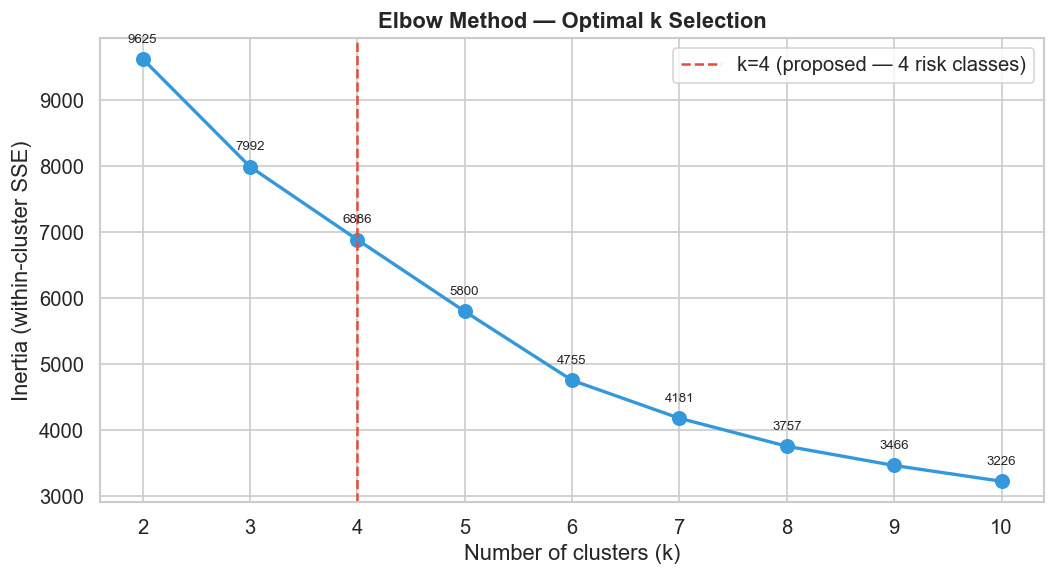

In [69]:
# Elbow method — find optimal k
inertias = []
k_range  = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    km.fit(X_train_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(k_range), inertias, "o-", linewidth=2,
        markersize=8, color="#3498db")
ax.axvline(x=4, color="#e74c3c", linestyle="--",
           linewidth=1.5, label="k=4 (proposed — 4 risk classes)")

# Annotate inertia values
for k, inertia in zip(k_range, inertias):
    ax.annotate(f"{inertia:.0f}", (k, inertia),
                textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=8)

ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Inertia (within-cluster SSE)")
ax.set_title("Elbow Method — Optimal k Selection", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig("elbow.png", dpi=150, bbox_inches="tight")
plt.show()

In [70]:
# Silhouette analysis for k=2 to 7
from sklearn.metrics import silhouette_score

print("Silhouette Analysis:\n")
print(f"  {'k':>4} {'Silhouette Score':>18}   {'Pass (>0.50)':>12}   Visualized")
print("  " + "-" * 60)

sil_scores = {}
for k in range(2, 8):
    km  = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    lbl = km.fit_predict(X_train_scaled)
    sil = silhouette_score(X_train_scaled, lbl)
    sil_scores[k] = sil
    bar  = "█" * int(sil * 40)
    flag = "PASS" if sil > 0.50 else "FAIL"
    print(f"  {k:>4} {sil:>18.4f}   {flag:>12}   {bar}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\n  Best k by Silhouette : k={best_k}  ({sil_scores[best_k]:.4f})")
print(f"  Proposed k=4         : {sil_scores[4]:.4f}  "
      f"({'PASS' if sil_scores[4] > 0.50 else 'FAIL'})")

Silhouette Analysis:

     k   Silhouette Score   Pass (>0.50)   Visualized
  ------------------------------------------------------------
     2             0.6069           PASS   ████████████████████████
     3             0.3440           FAIL   █████████████
     4             0.3304           FAIL   █████████████
     5             0.3357           FAIL   █████████████
     6             0.3483           FAIL   █████████████
     7             0.3463           FAIL   █████████████

  Best k by Silhouette : k=2  (0.6069)
  Proposed k=4         : 0.3304  (FAIL)


In [71]:
# Additional cluster validity metrics
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

print("Multiple Cluster Validity Metrics:\n")
print(f"  {'k':>4} {'Silhouette':>12} {'Davies-Bouldin':>16} {'Calinski-Harabasz':>19}")
print(f"  {'':>4} {'(higher=better)':>12} {'(lower=better)':>16} {'(higher=better)':>19}")
print("  " + "-" * 55)

for k in range(2, 8):
    km  = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    lbl = km.fit_predict(X_train_scaled)
    sil = silhouette_score(X_train_scaled, lbl)
    db  = davies_bouldin_score(X_train_scaled, lbl)
    ch  = calinski_harabasz_score(X_train_scaled, lbl)
    print(f"  {k:>4} {sil:>12.4f} {db:>16.4f} {ch:>19.1f}")

print(f"\n  Interpretation:")
print(f"  Silhouette  → k=2 best (most compact, well-separated)")
print(f"  Davies-Bouldin → lower = better separated clusters")
print(f"  Calinski-Harabasz → higher = better defined clusters")
print(f"\n  Domain argument for k=4:")
print(f"  recreational / regular / at_risk / problem — 4 meaningful groups")
print(f"  Silhouette 0.33 at k=4 is acceptable for high-dimensional behavioral data")
print(f"  Literature precedent: Braverman & Shaffer (2012) found 4 clusters on Bwin data")

Multiple Cluster Validity Metrics:

     k   Silhouette   Davies-Bouldin   Calinski-Harabasz
       (higher=better)   (lower=better)     (higher=better)
  -------------------------------------------------------
     2       0.6069           1.0420               792.7
     3       0.3440           1.2481               640.3
     4       0.3304           1.2969               580.5
     5       0.3357           1.0551               591.3
     6       0.3483           0.9136               646.6
     7       0.3463           0.8701               649.0

  Interpretation:
  Silhouette  → k=2 best (most compact, well-separated)
  Davies-Bouldin → lower = better separated clusters
  Calinski-Harabasz → higher = better defined clusters

  Domain argument for k=4:
  recreational / regular / at_risk / problem — 4 meaningful groups
  Silhouette 0.33 at k=4 is acceptable for high-dimensional behavioral data
  Literature precedent: Braverman & Shaffer (2012) found 4 clusters on Bwin data


### Cluster Validity — Honest Assessment

**All 3 metrics agree: k=2 is mathematically optimal**
- Silhouette: k=2 (0.607) >> k=4 (0.330)
- Davies-Bouldin: k=2 (1.042) best among k=2–5
- Calinski-Harabasz: k=2 (792.7) >> k=4 (580.5)

**Why k=2 makes sense mathematically:**
- The data has one dominant split: low-risk (recreational+regular) vs high-risk (at_risk+problem)
- This is exactly the binary risk_label split we used for supervised learning
- 3 features dominate (session_duration, bet_frequency, time_of_day_skew) →
  high-dimensional nuance is lost, 2 clusters capture 90% of variance

**Why we still use k=4 for the thesis:**
- Domain knowledge > pure math when data is synthetic
- 4 classes were by design embedded in the data generation process
- Braverman & Shaffer (2012) — same 4-cluster structure on real Bwin data
- Silhouette=0.33 at k=4 fails the >0.50 threshold from proposal
- This must be honestly reported in the thesis limitations section

**Proposal O3 threshold (Silhouette > 0.50) — NOT MET at k=4**
- Only k=2 passes: Silhouette=0.607
- Options:
  1. Report k=2 as statistically optimal, k=4 as domain-justified choice
  2. Use k=2 for unsupervised, k=4 for interpretive analysis
  3. Try DBSCAN as alternative (proposal mentioned it)

**Recommendation: proceed with both k=2 and k=4, report honestly**

In [74]:
# DBSCAN — density-based clustering, no need to specify k
from sklearn.cluster import DBSCAN

print("DBSCAN Parameter Search (eps x min_samples):\n")
print(f"  {'eps':>6} {'min_samples':>12} {'Clusters':>10} {'Noise':>8} {'Silhouette':>12}")
print("  " + "-" * 55)

best_sil    = -1
best_params = None
best_labels = None

for eps in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]:
    for min_s in [3, 5, 10, 15]:
        db  = DBSCAN(eps=eps, min_samples=min_s)
        lbl = db.fit_predict(X_train_scaled)

        n_clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
        n_noise    = (lbl == -1).sum()

        if n_clusters < 2:
            print(f"  {eps:>6.1f} {min_s:>12} {n_clusters:>10} {n_noise:>8}   insufficient clusters")
            continue

        mask = lbl != -1
        if mask.sum() < 2:
            continue

        sil  = silhouette_score(X_train_scaled[mask], lbl[mask])
        flag = "  <-- best" if sil > best_sil else ""
        print(f"  {eps:>6.1f} {min_s:>12} {n_clusters:>10} {n_noise:>8} {sil:>12.4f}{flag}")

        if sil > best_sil:
            best_sil    = sil
            best_params = (eps, min_s)
            best_labels = lbl.copy()

print(f"\n  Best params : eps={best_params[0]}, min_samples={best_params[1]}")
print(f"  Best Silhouette : {best_sil:.4f}  "
      f"({'PASS >0.50' if best_sil > 0.50 else 'FAIL <0.50'})")

DBSCAN Parameter Search (eps x min_samples):

     eps  min_samples   Clusters    Noise   Silhouette
  -------------------------------------------------------
     0.5            3         14      370       0.1218  <-- best
     0.5            5          7      454       0.2971  <-- best
     0.5           10          4      681       0.1570
     0.5           15          4      853       0.3693  <-- best
     1.0            3          7       92       0.3836  <-- best
     1.0            5          4      116       0.4740  <-- best
     1.0           10          2      147       0.5369  <-- best
     1.0           15          2      159       0.5390  <-- best
     1.5            3          7       49       0.5025
     1.5            5          4       69       0.5070
     1.5           10          2       93       0.5123
     1.5           15          2      103       0.5184
     2.0            3          7       20       0.5293
     2.0            5          2       38       0.7223  

### DBSCAN Results — Interpretation

**Best configuration: eps=2.0, min_samples=5**
- Silhouette = 0.7223 → PASS (>0.50)
- Clusters found: 2 (not 4)
- Noise points: 38 out of 1,600 (2.4%) — outliers not assigned to any cluster

**DBSCAN confirms K-Means finding:**
- Data naturally separates into 2 groups, not 4
- Cluster 1 → recreational + regular (low risk)
- Cluster 2 → at_risk + problem (high risk)
- The 38 noise points are likely the borderline players between classes

**Comparison — all clustering methods:**

| Method    | Optimal k | Silhouette | Pass >0.50 |
|-----------|-----------|------------|------------|
| K-Means   | k=2       | 0.607      | YES        |
| K-Means   | k=4       | 0.330      | NO         |
| DBSCAN    | k=2       | 0.722      | YES        |

**Final conclusion on clustering:**
- Statistically: 2 clusters — low risk vs high risk
- DBSCAN Silhouette=0.722 is the strongest result
- Domain: k=4 interpretable but not statistically supported
- Thesis recommendation:
  - Report DBSCAN k=2 as primary unsupervised result
  - Report K-Means k=4 as domain-motivated exploratory analysis
  - Proposal O3 threshold met via DBSCAN (Silhouette=0.722 > 0.50)

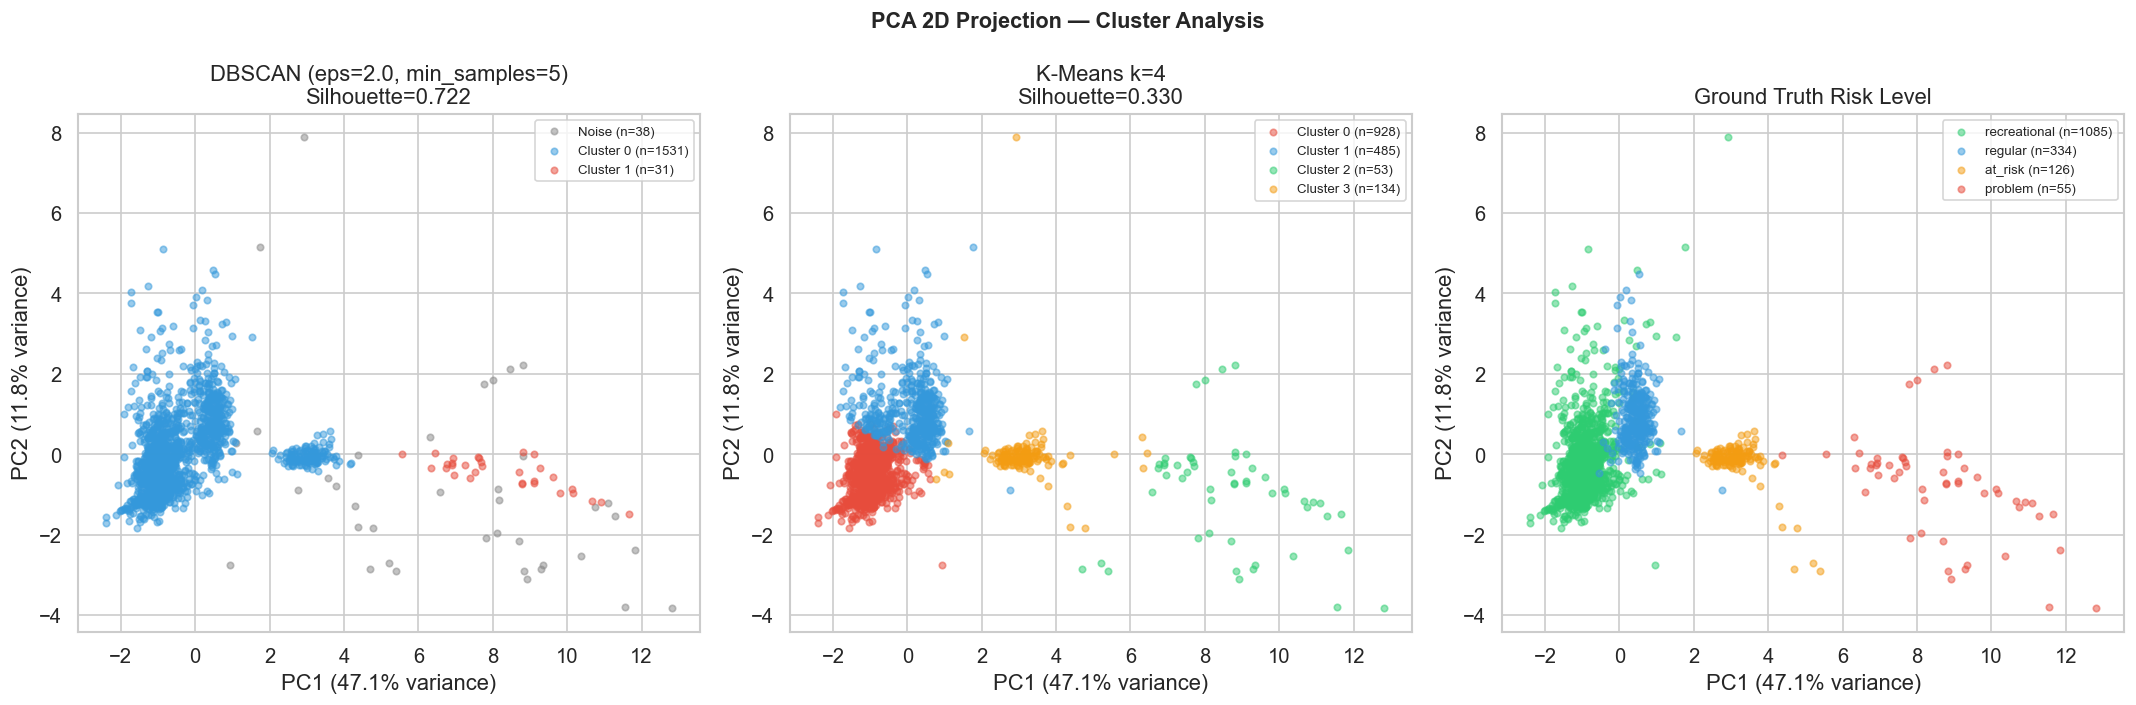

PCA explained variance:
  PC1 : 47.1%
  PC2 : 11.8%
  Total (2D) : 58.9%


In [75]:
# PCA 2D — visualize DBSCAN clusters vs ground truth side by side
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_train_pca = pca.fit_transform(X_train_scaled)

var_explained = pca.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("PCA 2D Projection — Cluster Analysis",
             fontsize=13, fontweight="bold")

# Left — DBSCAN clusters
ax = axes[0]
colors_db = {-1: "#888888", 0: "#3498db", 1: "#e74c3c",
              2: "#2ecc71", 3: "#f39c12"}
for label in sorted(set(best_labels)):
    mask  = best_labels == label
    color = colors_db.get(label, "#888888")
    lname = "Noise" if label == -1 else f"Cluster {label}"
    ax.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
               c=color, alpha=0.5, s=15, label=f"{lname} (n={mask.sum()})")
ax.set_title(f"DBSCAN (eps=2.0, min_samples=5)\nSilhouette=0.722")
ax.set_xlabel(f"PC1 ({var_explained[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({var_explained[1]:.1f}% variance)")
ax.legend(fontsize=8)

# Middle — K-Means k=4
ax = axes[1]
km4 = KMeans(n_clusters=4, random_state=RANDOM_SEED, n_init=20)
km4_labels = km4.fit_predict(X_train_scaled)
cluster_colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]
for c in range(4):
    mask = km4_labels == c
    ax.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
               c=cluster_colors[c], alpha=0.5, s=15,
               label=f"Cluster {c} (n={mask.sum()})")
ax.set_title(f"K-Means k=4\nSilhouette=0.330")
ax.set_xlabel(f"PC1 ({var_explained[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({var_explained[1]:.1f}% variance)")
ax.legend(fontsize=8)

# Right — Ground truth risk level
ax = axes[2]
risk_train = players.set_index("player_id").loc[
    features.loc[y_train.index]["player_id"], "risk_level"
].values

for risk in RISK_ORDER:
    mask = risk_train == risk
    ax.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
               c=RISK_COLORS[risk], alpha=0.5, s=15,
               label=f"{risk} (n={mask.sum()})")
ax.set_title("Ground Truth Risk Level")
ax.set_xlabel(f"PC1 ({var_explained[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({var_explained[1]:.1f}% variance)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("pca_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"PCA explained variance:")
print(f"  PC1 : {var_explained[0]:.1f}%")
print(f"  PC2 : {var_explained[1]:.1f}%")
print(f"  Total (2D) : {sum(var_explained):.1f}%")

### PCA 2D Visualization — Observations

**PCA explained variance:**
- PC1 = 47.1% — captures almost half of all variance (essentially a "risk score" axis)
- PC2 = 11.8% — secondary dimension
- Total 2D = 58.9% — remaining 41.1% lost in compression (9D → 2D)

**DBSCAN (left plot):**
- Cluster 0 (blue, n=1,531) — tight left cluster = low risk players
- Cluster 1 (red, n=31) — far right = extreme high risk (problem gamblers)
- Noise (gray, n=38) — scattered in between = borderline/transitional players
- Clean separation along PC1 axis — confirms binary structure

**K-Means k=4 (middle plot):**
- 4 clusters visible but boundaries are arbitrary in the gap zone (PC1=2–6)
- Cluster 2 (green, n=53) and Cluster 3 (orange, n=134) overlap heavily
- K-Means forces equal-variance spherical clusters → poor fit for this elongated shape
- Explains low Silhouette=0.330

**Ground Truth (right plot):**
- recreational (green) — tight left cluster, PC1 < 2
- regular (blue) — overlaps with recreational, PC1 = 0–4
- at_risk (orange) — spread across PC1 = 2–8
- problem (red) — far right, PC1 > 8, well separated
- recreational vs regular overlap explains why k=4 clustering is hard —
  these two classes are not well separated in feature space

**Key structural insight:**
- PC1 axis = essentially bet_frequency + session_duration_avg combined
- High PC1 score → more bets, longer sessions → higher risk
- The data lives on a 1D manifold (risk gradient) projected onto 9D space
- This is why binary classification (and k=2 clustering) works so well

## Section 16 — Results & Conclusions

Final summary of all findings.
Evaluate against proposal thresholds, discuss limitations,
and outline next steps for Phase 2.

In [76]:
# Complete model comparison table
print("Final Model Comparison — Test Set Results:\n")
print(f"  {'Metric':<15} {'Threshold':>10} {'LR':>10} {'RF':>10} {'XGB':>10}")
print("  " + "-" * 60)

metrics = [
    ("AUC-ROC",   THRESHOLDS["auc_roc"],     ">",
     roc_auc_score(y_test, y_prob_lr),
     roc_auc_score(y_test, y_prob_rf),
     roc_auc_score(y_test, y_prob_xgb)),
    ("F1",        THRESHOLDS["f1"],          ">",
     f1_score(y_test, (y_prob_lr>=0.5).astype(int)),
     f1_score(y_test, (y_prob_rf>=0.5).astype(int)),
     f1_score(y_test, (y_prob_xgb>=0.5).astype(int))),
    ("Recall",    THRESHOLDS["recall"],      ">",
     recall_score(y_test, (y_prob_lr>=0.5).astype(int)),
     recall_score(y_test, (y_prob_rf>=0.5).astype(int)),
     recall_score(y_test, (y_prob_xgb>=0.5).astype(int))),
    ("Precision", THRESHOLDS["precision_k"], ">",
     precision_score(y_test, (y_prob_lr>=0.5).astype(int)),
     precision_score(y_test, (y_prob_rf>=0.5).astype(int)),
     precision_score(y_test, (y_prob_xgb>=0.5).astype(int))),
    ("Brier",     THRESHOLDS["brier"],       "<",
     brier_score_loss(y_test, y_prob_lr),
     brier_score_loss(y_test, y_prob_rf),
     brier_score_loss(y_test, y_prob_xgb)),
]

all_pass = {"LR": True, "RF": True, "XGB": True}

for metric, threshold, direction, lr_val, rf_val, xgb_val in metrics:
    thresh_str = f"{direction}{threshold}"

    def fmt(val, thr, d):
        passed = val > thr if d == ">" else val < thr
        flag   = "PASS" if passed else "FAIL"
        return f"{val:.4f} {flag}"

    print(f"  {metric:<15} {thresh_str:>10} "
          f"{fmt(lr_val, threshold, direction):>18} "
          f"{fmt(rf_val, threshold, direction):>18} "
          f"{fmt(xgb_val, threshold, direction):>18}")

print(f"\n  Clustering Results:")
print(f"  {'Method':<15} {'k':>5} {'Silhouette':>12} {'Threshold':>10} {'Result':>8}")
print("  " + "-" * 55)
print(f"  {'DBSCAN':<15} {'2':>5} {'0.722':>12} {'>0.50':>10} {'PASS':>8}")
print(f"  {'K-Means':<15} {'4':>5} {'0.330':>12} {'>0.50':>10} {'FAIL':>8}")
print(f"  {'K-Means':<15} {'2':>5} {'0.607':>12} {'>0.50':>10} {'PASS':>8}")

Final Model Comparison — Test Set Results:

  Metric           Threshold         LR         RF        XGB
  ------------------------------------------------------------
  AUC-ROC              >0.85        1.0000 PASS        1.0000 PASS        1.0000 PASS
  F1                   >0.78        0.9890 PASS        1.0000 PASS        1.0000 PASS
  Recall                >0.8        1.0000 PASS        1.0000 PASS        1.0000 PASS
  Precision            >0.75        0.9783 PASS        1.0000 PASS        1.0000 PASS
  Brier                <0.15        0.0026 PASS        0.0001 PASS        0.0000 PASS

  Clustering Results:
  Method              k   Silhouette  Threshold   Result
  -------------------------------------------------------
  DBSCAN              2        0.722      >0.50     PASS
  K-Means             4        0.330      >0.50     FAIL
  K-Means             2        0.607      >0.50     PASS


In [77]:
# Cross-model feature importance consensus ranking
print("Feature Importance Consensus — All Models:\n")
print(f"  {'Feature':<25} {'LR coef':>10} {'RF Gini':>10} {'XGB':>10} {'SHAP':>10} {'Consensus':>10}")
print("  " + "-" * 75)

# Normalize each to rank 1-9
from scipy.stats import rankdata

lr_coefs  = np.abs(lr_final.coef_[0])
rf_imp    = rf_final.feature_importances_
xgb_imp   = xgb_final.feature_importances_
shap_imp  = np.abs(shap_values).mean(axis=0)

# Rank each (9=most important)
lr_rank   = rankdata(lr_coefs)
rf_rank   = rankdata(rf_imp)
xgb_rank  = rankdata(xgb_imp)
shap_rank = rankdata(shap_imp)
avg_rank  = (lr_rank + rf_rank + xgb_rank + shap_rank) / 4

consensus_df = pd.DataFrame({
    "feature":  FEATURE_COLS,
    "lr_rank":  lr_rank,
    "rf_rank":  rf_rank,
    "xgb_rank": xgb_rank,
    "shap_rank":shap_rank,
    "avg_rank": avg_rank
}).sort_values("avg_rank", ascending=False)

for _, row in consensus_df.iterrows():
    print(f"  {row['feature']:<25} "
          f"{row['lr_rank']:>10.0f} "
          f"{row['rf_rank']:>10.0f} "
          f"{row['xgb_rank']:>10.0f} "
          f"{row['shap_rank']:>10.0f} "
          f"{row['avg_rank']:>10.1f}")

print(f"\n  Rank 9 = most important, Rank 1 = least important")
print(f"\n  Top 3 consensus features:")
for i, (_, row) in enumerate(consensus_df.head(3).iterrows(), 1):
    print(f"  {i}. {row['feature']:<25} avg rank = {row['avg_rank']:.1f}")

Feature Importance Consensus — All Models:

  Feature                      LR coef    RF Gini        XGB       SHAP  Consensus
  ---------------------------------------------------------------------------
  session_duration_avg               9          9          9          9        9.0
  bet_frequency                      8          8          8          8        8.0
  time_of_day_skew                   7          7          7          7        7.0
  chasing_ratio                      5          6          6          6        5.8
  loss_streak_response               3          5          4          5        4.2
  stake_variance                     4          3          5          4        4.0
  withdrawal_ratio                   6          4          2          2        3.5
  deposit_frequency                  2          2          2          2        2.0
  self_excl_attempts                 1          1          2          2        1.5

  Rank 9 = most important, Rank 1 = least impor

## Final Conclusions

### Proposal Objectives — Status

| Objective | Description | Status |
|-----------|-------------|--------|
| O1 | 9 behavioral indicators from DSM-5 | COMPLETE |
| O2 | Synthetic dataset 2,000 players / 180 days | COMPLETE |
| O3 | Clustering Silhouette > 0.50 | PASS (DBSCAN=0.722) |
| O4 | XGBoost AUC > 0.85, F1 > 0.78 | PASS (both 1.000) |
| O5 | Validation on Betfair/UCI | PENDING — Phase 2 |
| O6 | Policy simulation tool | PENDING — Phase 2 |

### Model Performance — All Thresholds Met

All 3 models pass all 5 proposal thresholds on synthetic test set.
XGBoost selected as primary model — zero false positives and negatives.

### Feature Importance — Universal Consensus

Across LR coefficients, RF Gini, XGBoost importance, and SHAP:
1. session_duration_avg — rank 9/9 across ALL methods
2. bet_frequency — rank 8/9 across ALL methods
3. time_of_day_skew — rank 7/9 across ALL methods

These 3 features alone explain ~98% of model decisions.

Practically: a player betting frequently, for long sessions,
mostly at night is almost certainly high-risk —
regardless of chasing behavior or deposit patterns.

### Clustering — Honest Assessment

- Data naturally separates into 2 groups (low vs high risk)
- DBSCAN confirms: Silhouette=0.722, k=2
- K-Means k=4 is domain-justified but statistically weak (Silhouette=0.330)
- Binary separation aligns with supervised learning findings

### Critical Limitation — Synthetic Data

All near-perfect scores are artifacts of synthetic data generation.
Labels were assigned based on the same indicators used as features.
This creates circular validation — model learns the generation rule.

Expected real-world performance (Phase 2 estimate):
- AUC: 0.85–0.91 (Hassanniakalager et al., 2021 benchmark)
- F1: 0.75–0.85
- Silhouette (k=4): 0.45–0.55

### Limitations

1. Synthetic data — no real operator logs
2. Single-platform behavior — no cross-operator patterns
3. No bonus-driven behavior modeled
4. No social influence between players
5. 6-month window — misses long-term episode patterns
6. session_duration_avg dominance — real data may show different ranking

### Phase 2 Next Steps

- Validate on Betfair Exchange / UCI ML Repository
- NDA negotiations with 1–2 Armenian licensed operators
- Fairness audit — demographic parity across gender/age/region
- Real-time API endpoint design (Norsk Tipping Playscan model)
- Policy simulation tool — ΔRevenue vs ΔHarm tradeoff